# Exploratory Data Analysis ( EDA )

### Dataset Overview

In [1]:
import pandas as pd
df = pd.read_csv('./data/retail_large_dataset.csv')
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


### Key Findings

- The dataset represents **e-commerce retail transactions**, as indicated by features related to customer information, product details, order processing, payment methods, shipping, and returns.

- Each record corresponds to a **single customer order**, containing details about the customer, purchased product, pricing, payment, shipping, and order outcome.

- The dataset captures the complete **order lifecycle**, starting from customer demographics and purchase details to delivery and return status.

- Customer-related attributes such as **Customer ID, Age, Gender, City, State, and Customer Segment** enable customer profiling and segmentation analysis.

- Product-related features including **Product Category, Product Subcategory, Product Price, Quantity, Discount Percentage, and Final Price** facilitate sales, pricing, and revenue analysis.

- Transaction-related attributes such as **Order ID, Order Date, and Payment Method** provide insights into purchasing patterns, customer payment preferences, and sales trends over time.

- Logistics-related variables including **Shipping Type** and **Delivery Days** make it possible to evaluate shipping efficiency and delivery performance.

- The presence of **Return Status** enables analysis of product return behavior, customer satisfaction, and operational effectiveness.

In [3]:
df.shape

(100000, 18)


### Key Findings

- The dataset consists of **100,000 customer transaction records** and **18 features**, providing a comprehensive representation of e-commerce operations.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  str    
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  str    
 3   city                 100000 non-null  str    
 4   state                100000 non-null  str    
 5   customer_segment     100000 non-null  str    
 6   order_id             100000 non-null  str    
 7   order_date           100000 non-null  str    
 8   product_category     100000 non-null  str    
 9   product_subcategory  100000 non-null  str    
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  str    
 15  shipping_type        100000 n

### Key Findings

- **Categorical Features:** 12
- **Numerical Features:** 6

- The **`order_date`** column is currently stored as a categorical (object/string) variable. Since it represents the date on which an order was placed, it should be converted to the **DateTime** data type to enable time-series analysis, monthly sales trends, seasonal analysis, and other date-based insights.

In [2]:
df['order_date']=pd.to_datetime(df['order_date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          100000 non-null  str           
 1   age                  100000 non-null  int64         
 2   gender               100000 non-null  str           
 3   city                 100000 non-null  str           
 4   state                100000 non-null  str           
 5   customer_segment     100000 non-null  str           
 6   order_id             100000 non-null  str           
 7   order_date           100000 non-null  datetime64[us]
 8   product_category     100000 non-null  str           
 9   product_subcategory  100000 non-null  str           
 10  product_price        100000 non-null  int64         
 11  quantity             100000 non-null  int64         
 12  discount_percentage  100000 non-null  int64         
 13  final_price          10000

In [3]:
# Missing values and percentage
missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': round((df.isnull().sum() / len(df)) * 100, 2)
})

missing_df = missing_df.sort_values(by='Missing Values', ascending=False)

missing_df

,Missing Values,Percentage (%)
customer_id,0,0.0
age,0,0.0
gender,0,0.0
city,0,0.0
state,0,0.0
customer_segment,0,0.0
order_id,0,0.0
order_date,0,0.0
product_category,0,0.0
product_subcategory,0,0.0


### Key Findings

- No missing values were identified across any of the 18 features in the dataset.
- All **100,000 records** are complete, indicating that the dataset is clean and does not require any missing value treatment.

In [8]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
age,100000.0,41.56183,18.0,30.0,42.0,54.0,65.0,13.852439
order_date,100000,2024-06-29 02:48:38.304000,2023-01-01 00:00:00,2023-09-30 00:00:00,2024-06-28 00:00:00,2025-03-30 00:00:00,2025-12-30 00:00:00,NaN
product_price,100000.0,30164.52672,500.0,15375.0,30148.0,44957.0,59998.0,17139.679807
quantity,100000.0,2.50179,1.0,1.0,3.0,4.0,4.0,1.120058
discount_percentage,100000.0,15.00989,0.0,7.0,15.0,23.0,30.0,8.953296
final_price,100000.0,64165.723382,357.0,24705.0,49752.39,94046.07,239980.0,49969.28015
delivery_days,100000.0,5.50554,1.0,3.0,5.0,8.0,10.0,2.872868


## Key Findings 

- The dataset contains transaction records from **1st January 2023** to **30th December 2025**, covering a period of approximately **three years**.
- The customer base primarily consists of **middle-aged adults** with a balanced age distribution.
- The business offers products across a **wide price range**, catering to both budget-conscious and premium customers.
- Customers generally purchase **2–3 products per order**, indicating moderate purchasing behavior.
- A consistent **15% discount strategy** appears to be followed across the platform.
- The presence of a few **high-value orders** contributes significantly to overall revenue, highlighting the importance of premium customers.
- Delivery performance is consistent, with most orders being fulfilled within **5–6 days**, reflecting an efficient logistics process.

In [17]:
outlier_summary = []

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        'Column': col,
        'Outliers': count,
        'Percentage (%)': round((count / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Column,Outliers,Percentage (%)
0,age,0,0.00
1,product_price,0,0.00
2,quantity,0,0.00
3,discount_percentage,0,0.00
4,final_price,1335,1.34
5,delivery_days,0,0.00


### Key Findings

- Among the six numerical features, only the **`final_price`** column contains outliers.
- A total of **1,335 observations (1.34% of the dataset)** were identified as outliers in the `final_price` feature.
- The presence of outliers in `final_price` is expected in an e-commerce dataset, as some orders may involve premium products, bulk purchases, or high-value transactions.
- Overall, the dataset exhibits a well-balanced distribution with minimal outlier influence, indicating good data quality.

### Univarient Analysis

In [3]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

Numerical Columns
Index(['age', 'product_price', 'quantity', 'discount_percentage',
       'final_price', 'delivery_days'],
      dtype='str')

Categorical Columns
Index(['customer_id', 'gender', 'city', 'state', 'customer_segment',
       'order_id', 'product_category', 'product_subcategory', 'payment_method',
       'shipping_type', 'return_status'],
      dtype='str')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13608\2672020122.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [4]:
exclude_cols = ["customer_id", "order_id"]

cat_cols = cat_cols.drop(exclude_cols)

print("\nUpdated Categorical Columns")
print(cat_cols)


Updated Categorical Columns
Index(['gender', 'city', 'state', 'customer_segment', 'product_category',
       'product_subcategory', 'payment_method', 'shipping_type',
       'return_status'],
      dtype='str')


In [5]:
distribution = pd.DataFrame({
    "Feature": num_cols,
    "Skewness": [df[col].skew() for col in num_cols],
    "Kurtosis": [df[col].kurt() for col in num_cols]
})

distribution = distribution.round(3)

# Interpretation Functions
def skew_type(x):
    if abs(x) < 0.5:
        return "Approximately Symmetric"
    elif abs(x) < 1:
        return "Moderately Skewed"
    else:
        return "Highly Skewed"

def kurtosis_type(x):
    if x < 0:
        return "Platykurtic"
    elif x < 3:
        return "Mesokurtic"
    else:
        return "Leptokurtic"

distribution["Skewness Interpretation"] = distribution["Skewness"].apply(skew_type)
distribution["Kurtosis Interpretation"] = distribution["Kurtosis"].apply(kurtosis_type)

distribution

,Feature,Skewness,Kurtosis,Skewness Interpretation,Kurtosis Interpretation
0,age,-0.005,-1.201,Approximately Symmetric,Platykurtic
1,product_price,0.003,-1.195,Approximately Symmetric,Platykurtic
2,quantity,-0.003,-1.365,Approximately Symmetric,Platykurtic
3,discount_percentage,-0.004,-1.202,Approximately Symmetric,Platykurtic
4,final_price,0.935,0.169,Moderately Skewed,Mesokurtic
5,delivery_days,0.002,-1.222,Approximately Symmetric,Platykurtic


### Key Findings: Skewness and Kurtosis Analysis

- Most numerical features are approximately symmetric, with skewness values close to zero.
- `final_price` is moderately positively skewed, indicating the presence of some higher-value transactions.
- The remaining numerical features show relatively balanced distributions with no significant skewness.
- Most features are platykurtic, indicating lighter tails and fewer extreme values.
- `final_price` is mesokurtic, showing a distribution with kurtosis close to that of a normal distribution.
- Overall, the numerical features exhibit well-balanced distributions, with `final_price` being the only feature requiring additional attention due to its moderate right skewness.

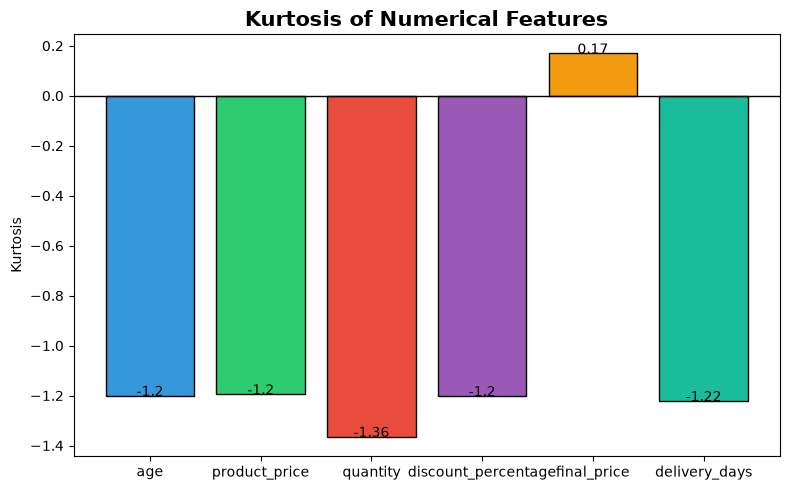

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    distribution["Feature"],
    distribution["Kurtosis"],
    color=['#3498db','#2ecc71','#e74c3c',
           '#9b59b6','#f39c12','#1abc9c'],
    edgecolor='black'
)

plt.axhline(0, color='black', linewidth=1)

plt.title("Kurtosis of Numerical Features",
          fontsize=15,
          fontweight='bold')

plt.ylabel("Kurtosis")

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             round(bar.get_height(),2),
             ha='center')

plt.tight_layout()
plt.show()

UNIVARIATE ANALYSIS : age
count    100000.000000
mean         41.561830
std          13.852439
min          18.000000
25%          30.000000
50%          42.000000
75%          54.000000
max          65.000000
Name: age, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18056\3361814754.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(


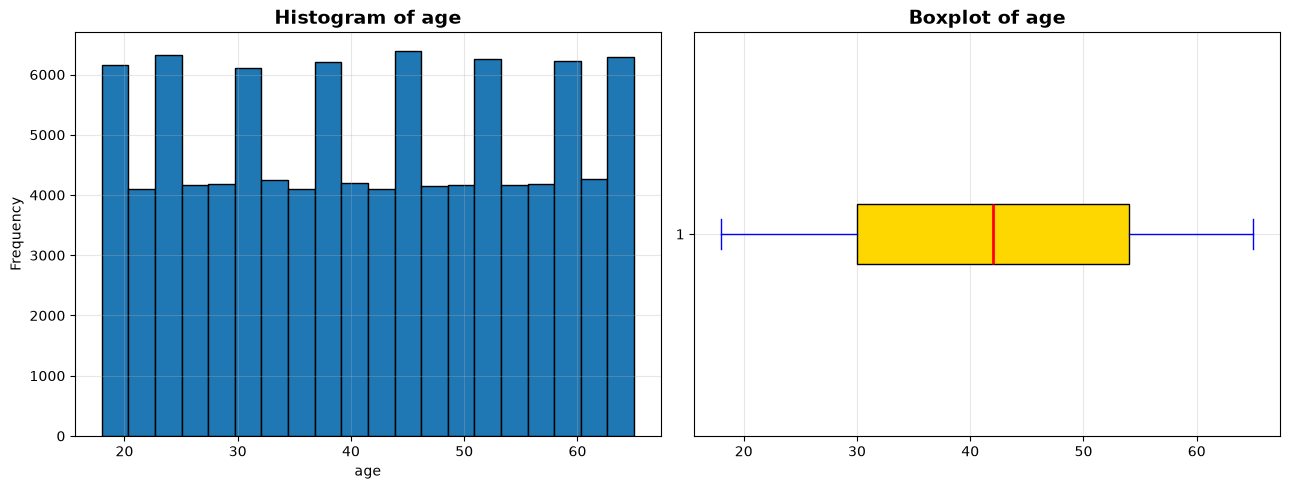

UNIVARIATE ANALYSIS : product_price
count    100000.000000
mean      30164.526720
std       17139.679807
min         500.000000
25%       15375.000000
50%       30148.000000
75%       44957.000000
max       59998.000000
Name: product_price, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18056\3361814754.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(


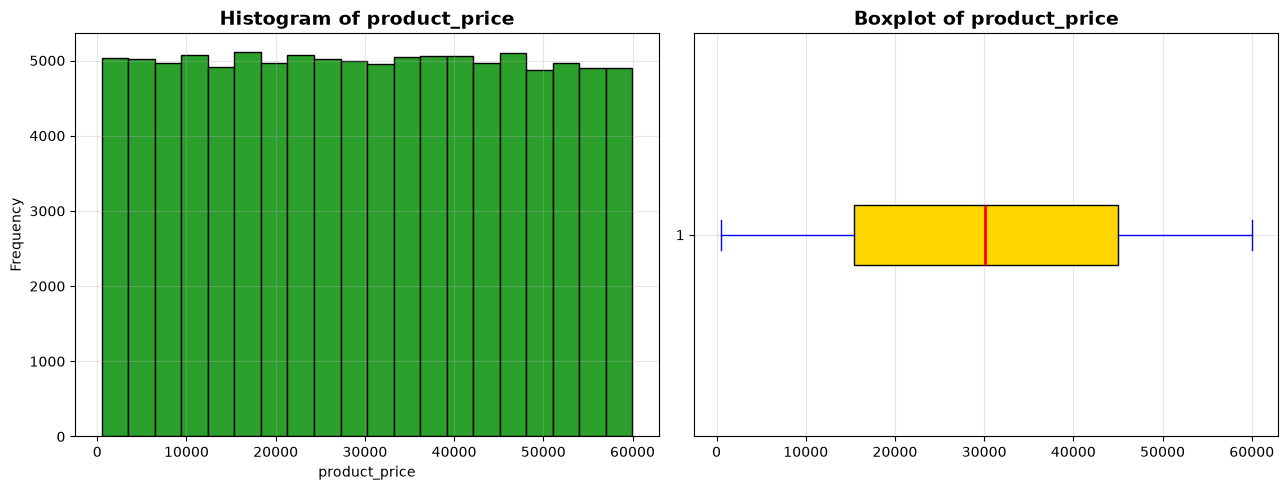

UNIVARIATE ANALYSIS : quantity
count    100000.000000
mean          2.501790
std           1.120058
min           1.000000
25%           1.000000
50%           3.000000
75%           4.000000
max           4.000000
Name: quantity, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18056\3361814754.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(


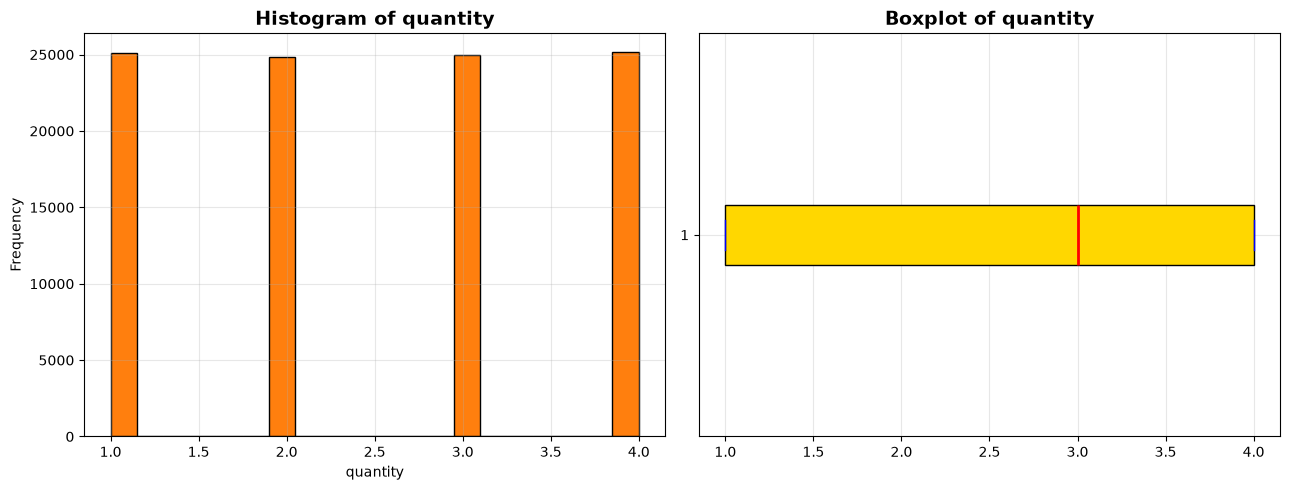

UNIVARIATE ANALYSIS : discount_percentage
count    100000.000000
mean         15.009890
std           8.953296
min           0.000000
25%           7.000000
50%          15.000000
75%          23.000000
max          30.000000
Name: discount_percentage, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18056\3361814754.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(


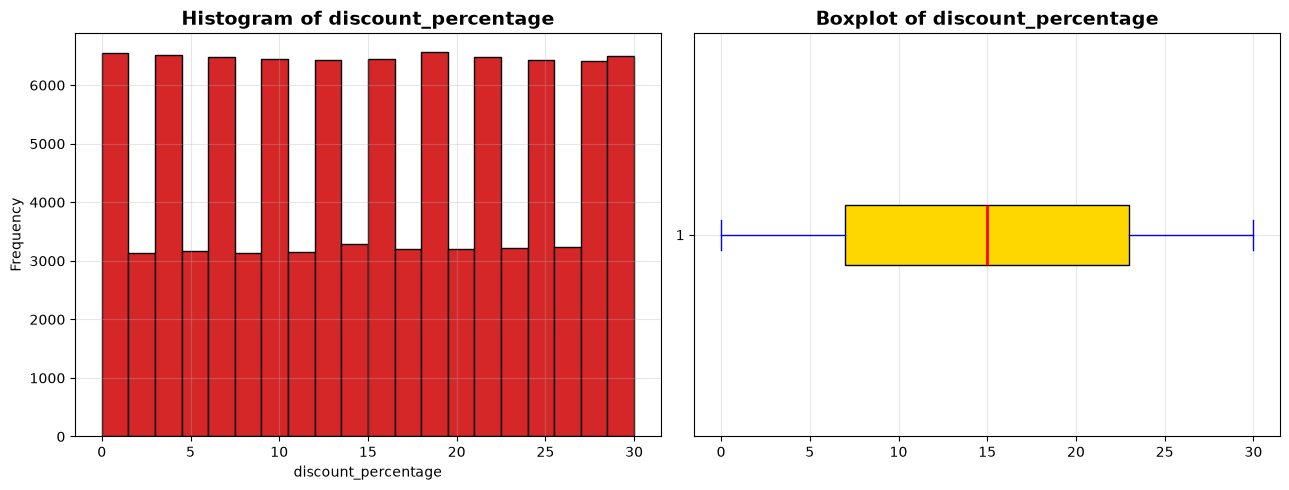

UNIVARIATE ANALYSIS : final_price
count    100000.000000
mean      64165.723382
std       49969.280150
min         357.000000
25%       24705.000000
50%       49752.390000
75%       94046.070000
max      239980.000000
Name: final_price, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18056\3361814754.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(


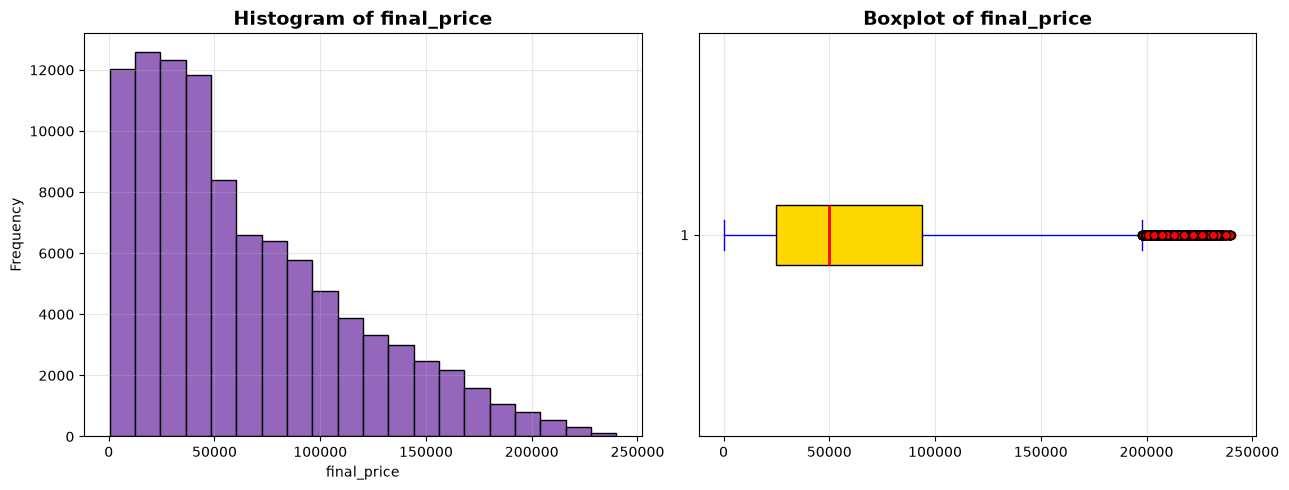

UNIVARIATE ANALYSIS : delivery_days
count    100000.000000
mean          5.505540
std           2.872868
min           1.000000
25%           3.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: delivery_days, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18056\3361814754.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(


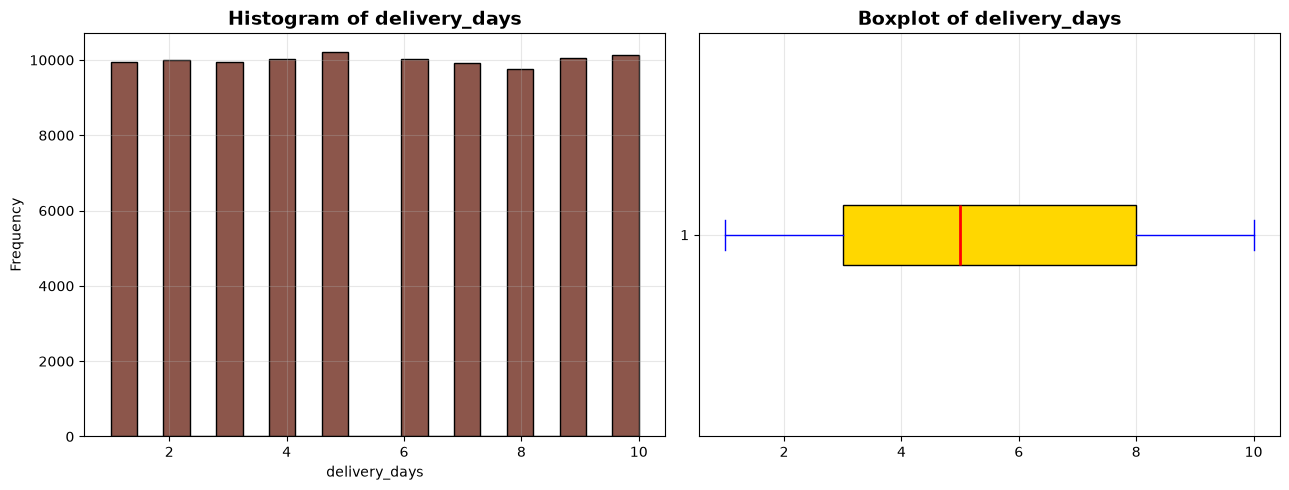

In [ ]:
# Colors for histogram
hist_colors = [
    '#1f77b4', '#2ca02c', '#ff7f0e', '#d62728',
    '#9467bd', '#8c564b', '#e377c2', '#17becf'
]

for i, col in enumerate(num_cols):

    print("="*80)
    print(f"UNIVARIATE ANALYSIS : {col}")
    print("="*80)

    print(df[col].describe())

    fig, ax = plt.subplots(1,2, figsize=(13,5))

    # Histogram
    ax[0].hist(
        df[col],
        bins=20,
        color=hist_colors[i % len(hist_colors)],
        edgecolor='black',
    )

    ax[0].set_title(f'Histogram of {col}', fontsize=14, fontweight='bold')
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Frequency")
    ax[0].grid(alpha=0.3)

    # Boxplot
    ax[1].boxplot(
        df[col],
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor='gold', color='black'),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(color='blue'),
        capprops=dict(color='blue'),
        flierprops=dict(marker='o', markerfacecolor='red', markersize=6)
    )

    ax[1].set_title(f'Boxplot of {col}', fontsize=14, fontweight='bold')
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [7]:
# Apply IQR Capping=
Q1 = df['final_price'].quantile(0.25)
Q3 = df['final_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

df['final_price'] = df['final_price'].clip(lower=lower_bound,
                                           upper=upper_bound)

print("Outliers have been capped successfully.")

Outliers have been capped successfully.


In [10]:
# Check outliers after capping

outliers_after = ((df['final_price'] < lower_bound) | (df['final_price'] > upper_bound)).sum()

print("Outliers After Capping:", outliers_after)

Outliers After Capping: 0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9824\903789330.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['final_price'],


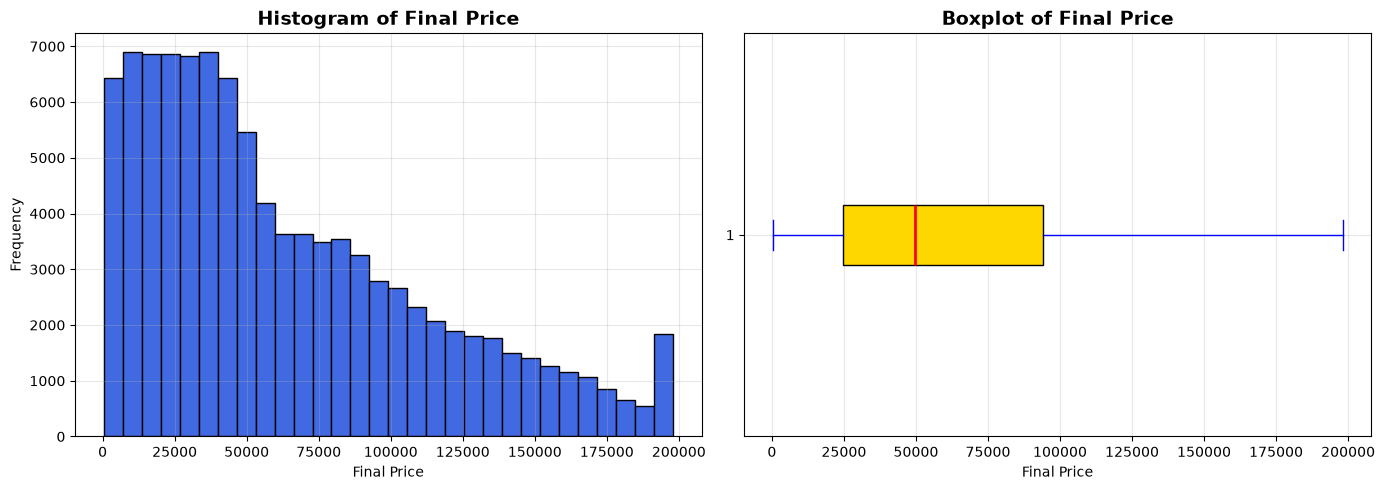

In [17]:
plt.figure(figsize=(14,5))

# Histogram
plt.subplot(1,2,1)
plt.hist(df['final_price'], bins=30,
         color='royalblue',
         edgecolor='black')
plt.title('Histogram of Final Price', fontsize=14, fontweight='bold')
plt.xlabel('Final Price')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

# Boxplot
plt.subplot(1,2,2)
plt.boxplot(df['final_price'],
            vert=False,
            patch_artist=True,
            boxprops=dict(facecolor='gold', edgecolor='black'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(marker='o',
                            markerfacecolor='red',
                            markersize=5))

plt.title('Boxplot of Final Price', fontsize=14, fontweight='bold')
plt.xlabel('Final Price')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Outlier Treatment

- Outliers in the **`final_price`** feature were handled using the **IQR Capping** method.
- Extreme values beyond the calculated IQR boundaries were replaced with the corresponding upper boundary value instead of being removed.
- This ensured that all **100,000 records** were retained while minimizing the impact of extreme values on the analysis.
- After capping, the `final_price` feature no longer contained outliers according to the IQR method.

UNIVARIATE ANALYSIS : gender
gender
Male      50111
Female    49889
Name: count, dtype: int64


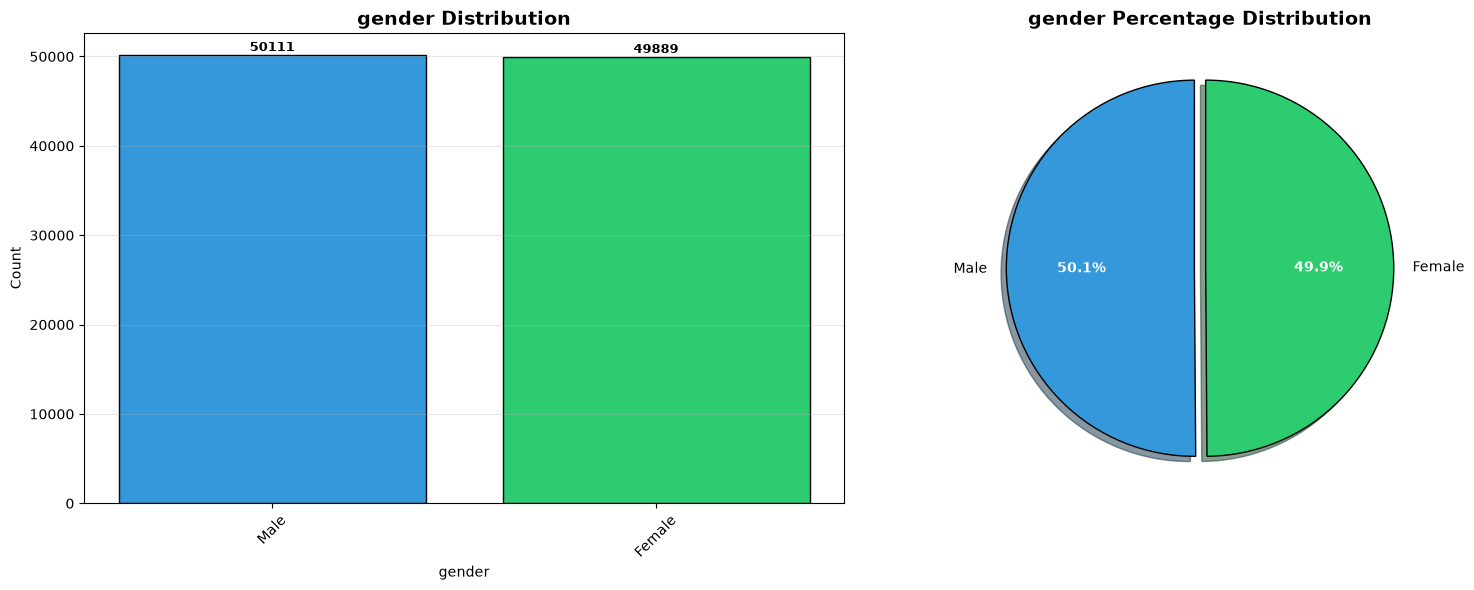

UNIVARIATE ANALYSIS : city
city
Hyderabad    10150
Ahmedabad    10057
Bangalore    10047
Mumbai       10015
Chennai       9993
Noida         9964
Delhi         9962
Kolkata       9955
Pune          9937
Jaipur        9920
Name: count, dtype: int64


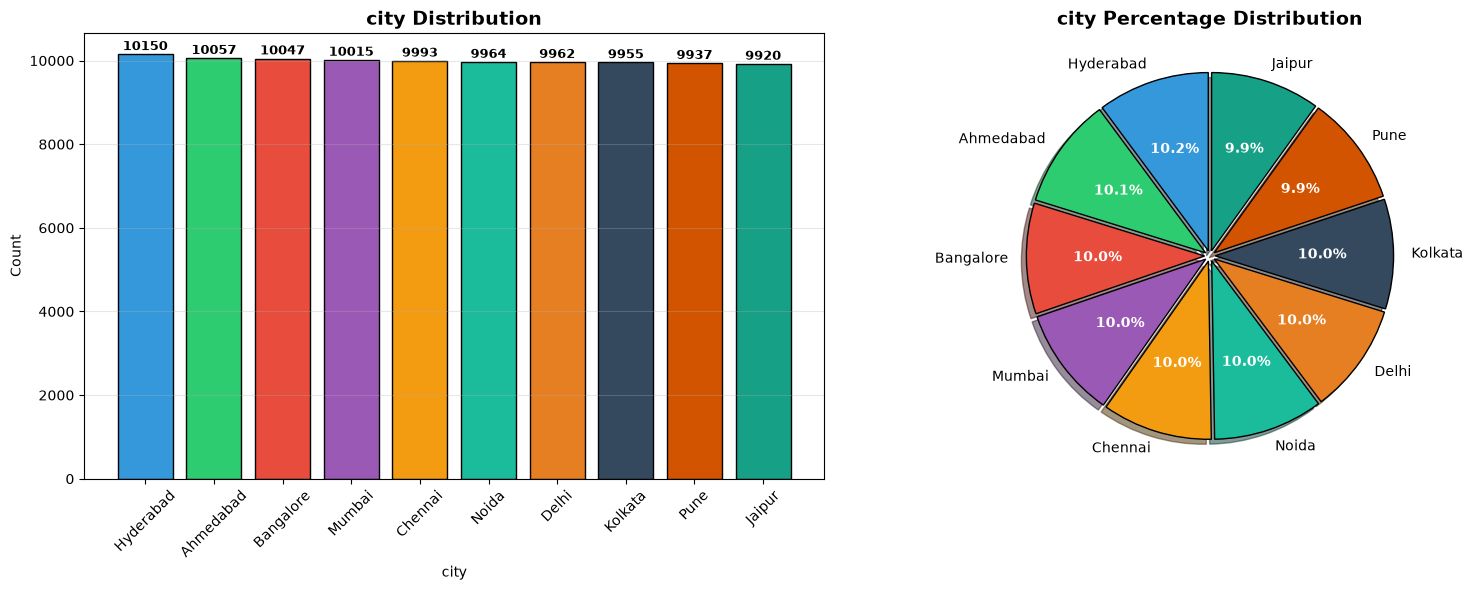

UNIVARIATE ANALYSIS : state
state
Maharashtra      19952
Telangana        10150
Gujarat          10057
Karnataka        10047
Tamil Nadu        9993
Uttar Pradesh     9964
Delhi             9962
West Bengal       9955
Rajasthan         9920
Name: count, dtype: int64


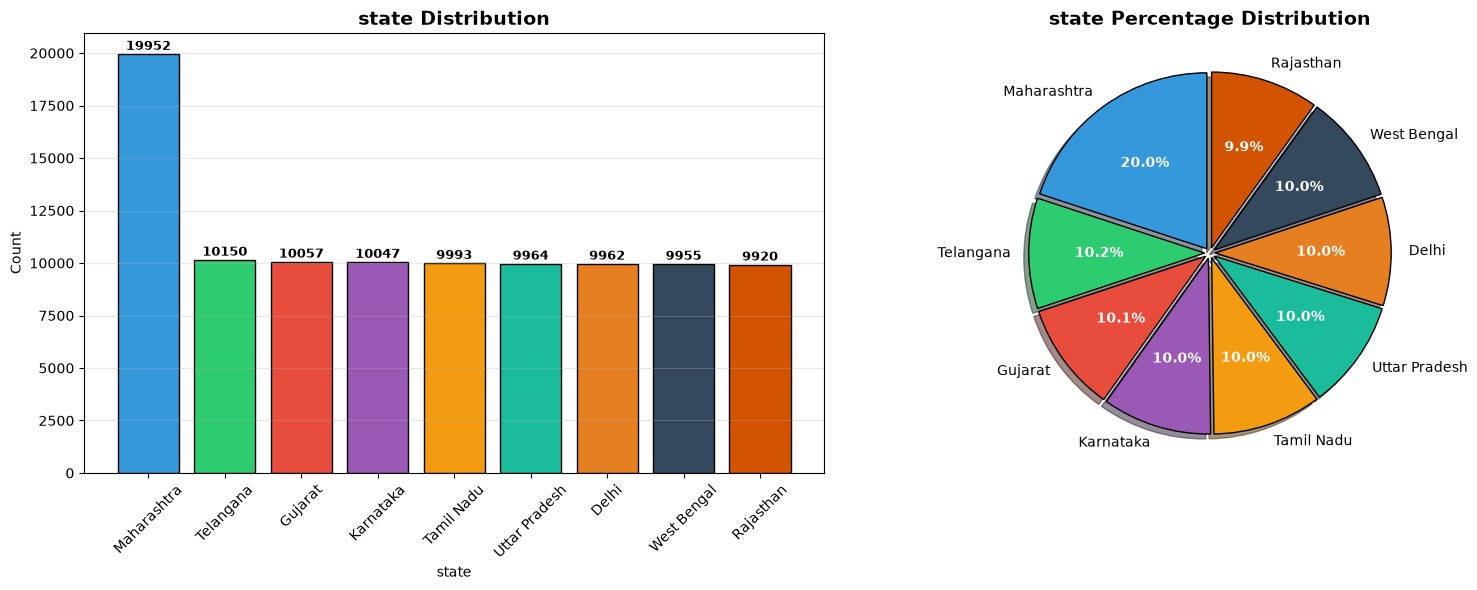

UNIVARIATE ANALYSIS : customer_segment
customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64


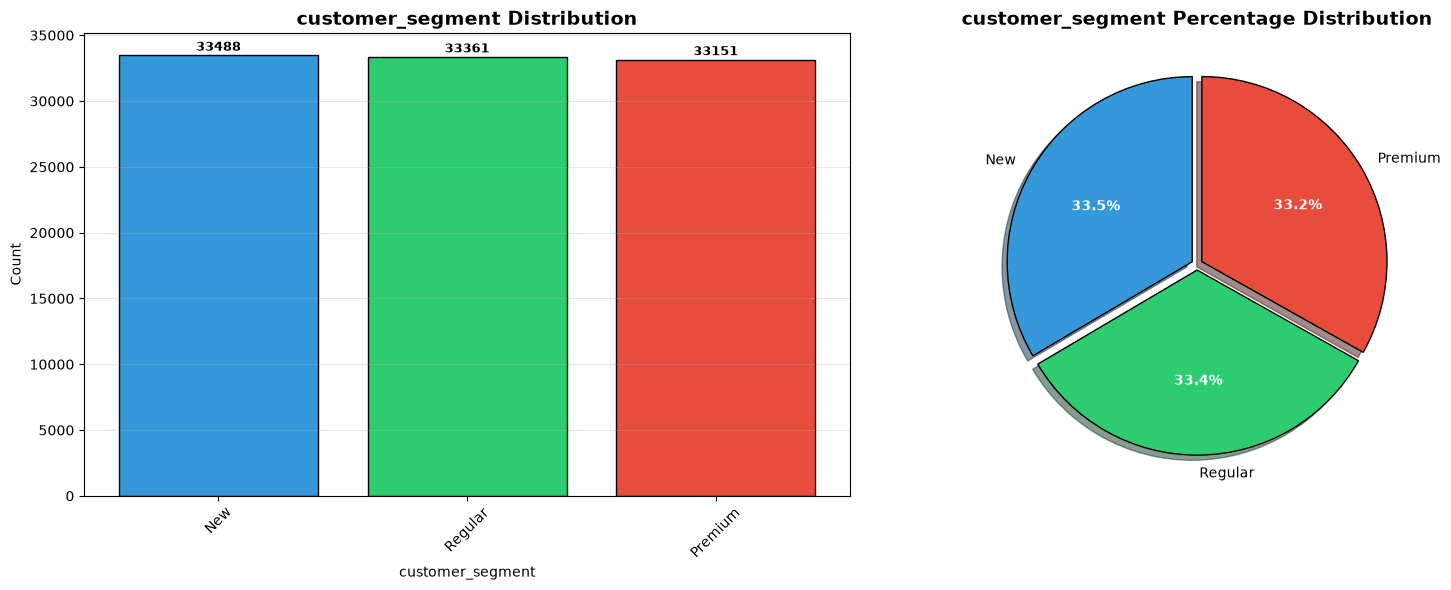

UNIVARIATE ANALYSIS : product_category
product_category
Health            16858
Home & Kitchen    16848
Fashion           16613
Grocery           16592
Electronics       16576
Beauty            16513
Name: count, dtype: int64


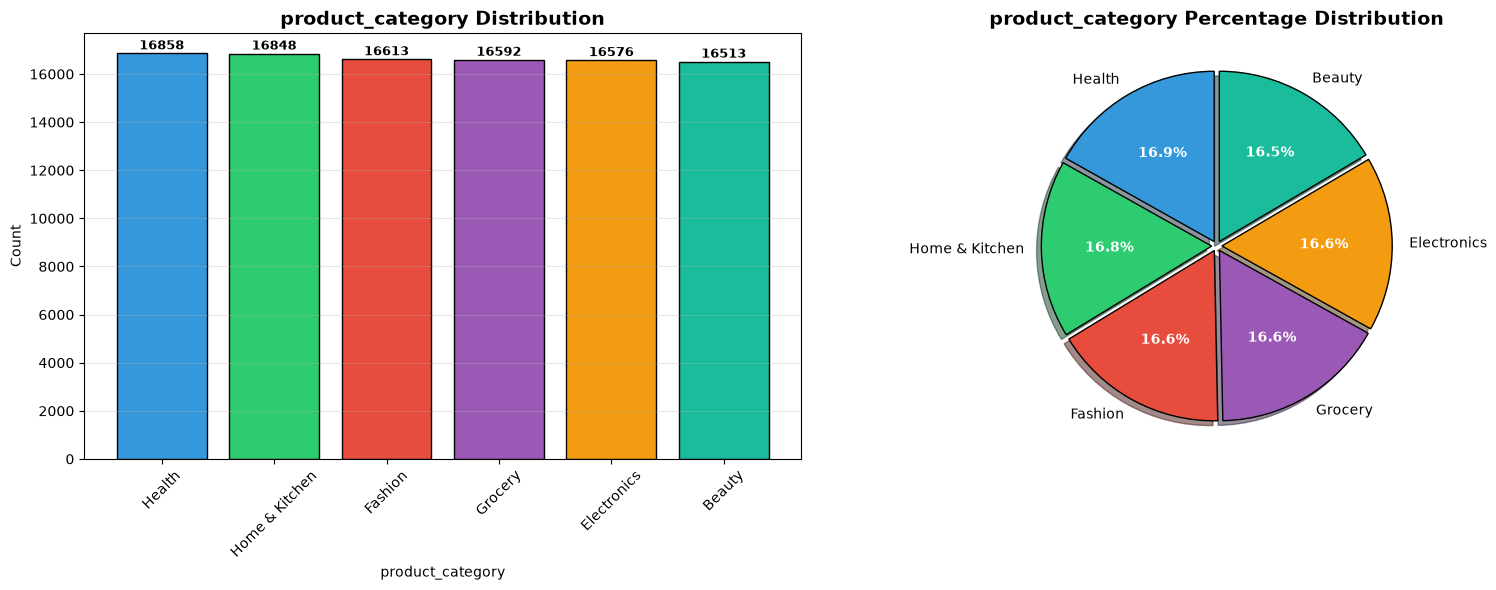

UNIVARIATE ANALYSIS : product_subcategory
product_subcategory
Protein Powder    5668
Supplements       5657
Shampoo           5578
Organic Rice      5567
Snacks            5548
Vitamins          5533
Face Cream        5512
Pulses            5477
Perfume           5423
Jeans             4278
Headphones        4265
Blender           4255
Cookware          4219
Vacuum Cleaner    4199
Smartphone        4198
Microwave         4175
Shoes             4145
Men T-Shirt       4132
Tablet            4070
Women Dress       4058
Laptop            4043
Name: count, dtype: int64


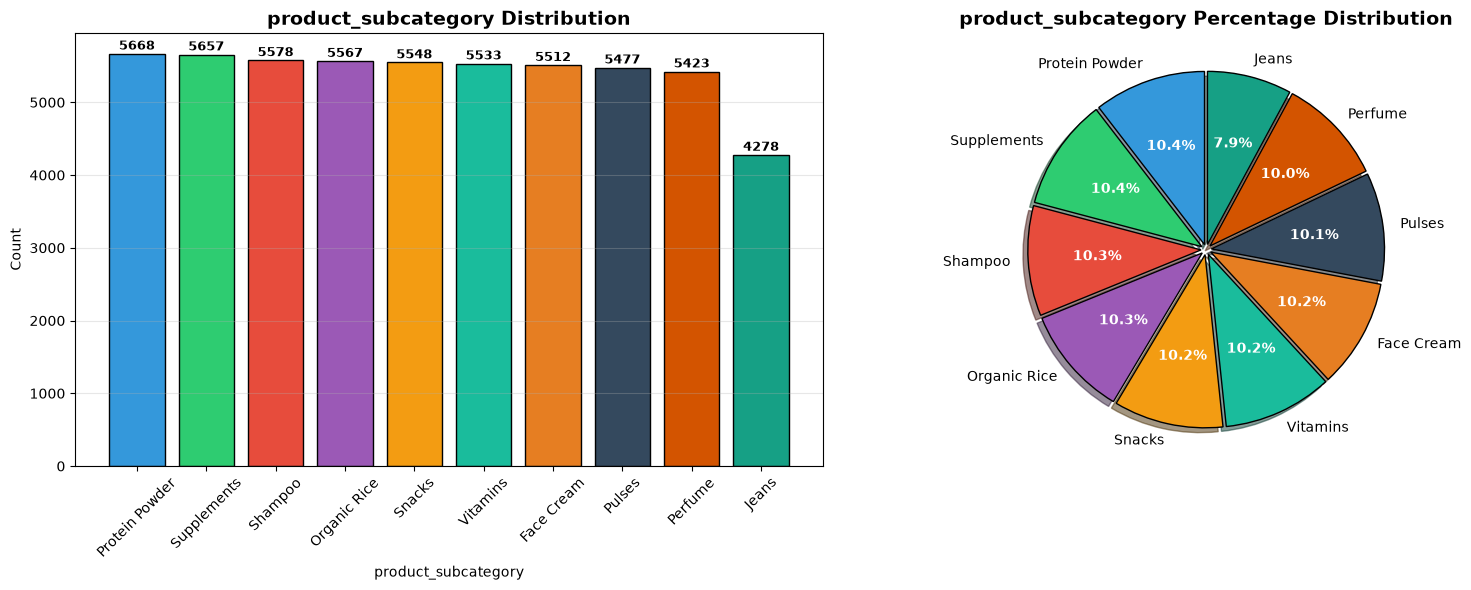

UNIVARIATE ANALYSIS : payment_method
payment_method
Credit Card         25307
UPI                 25139
Cash on Delivery    24994
Debit Card          24560
Name: count, dtype: int64


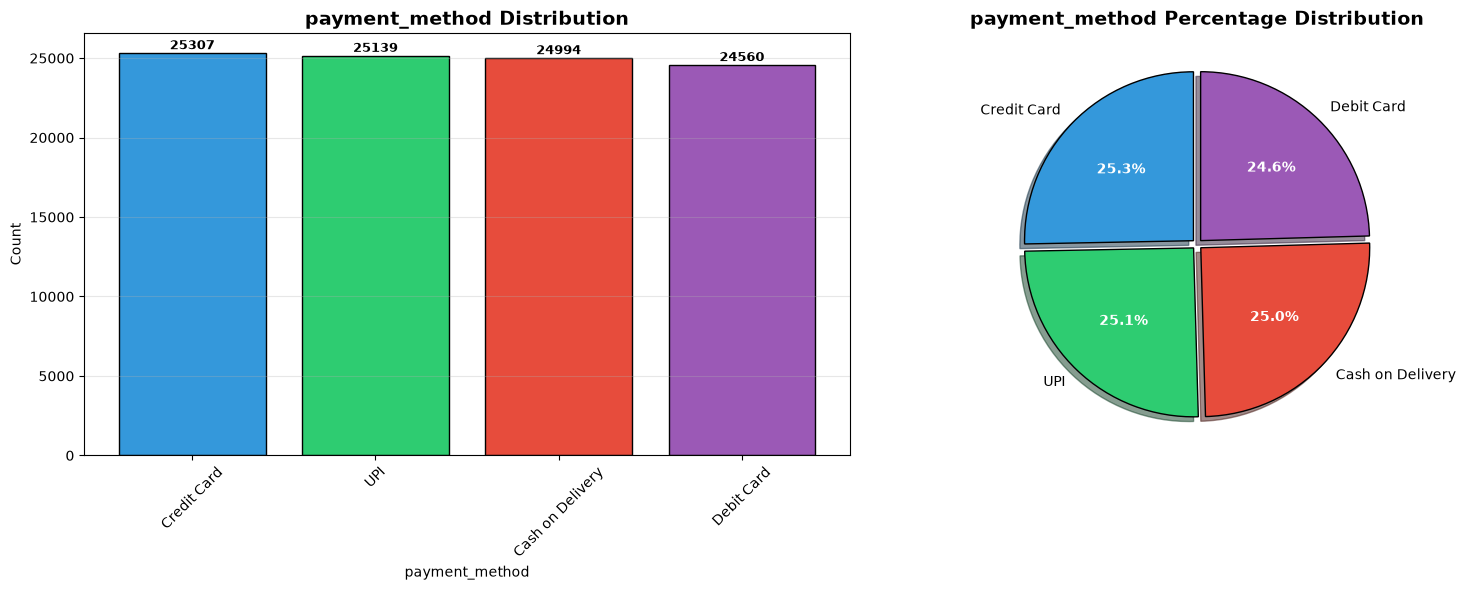

UNIVARIATE ANALYSIS : shipping_type
shipping_type
Express     50008
Standard    49992
Name: count, dtype: int64


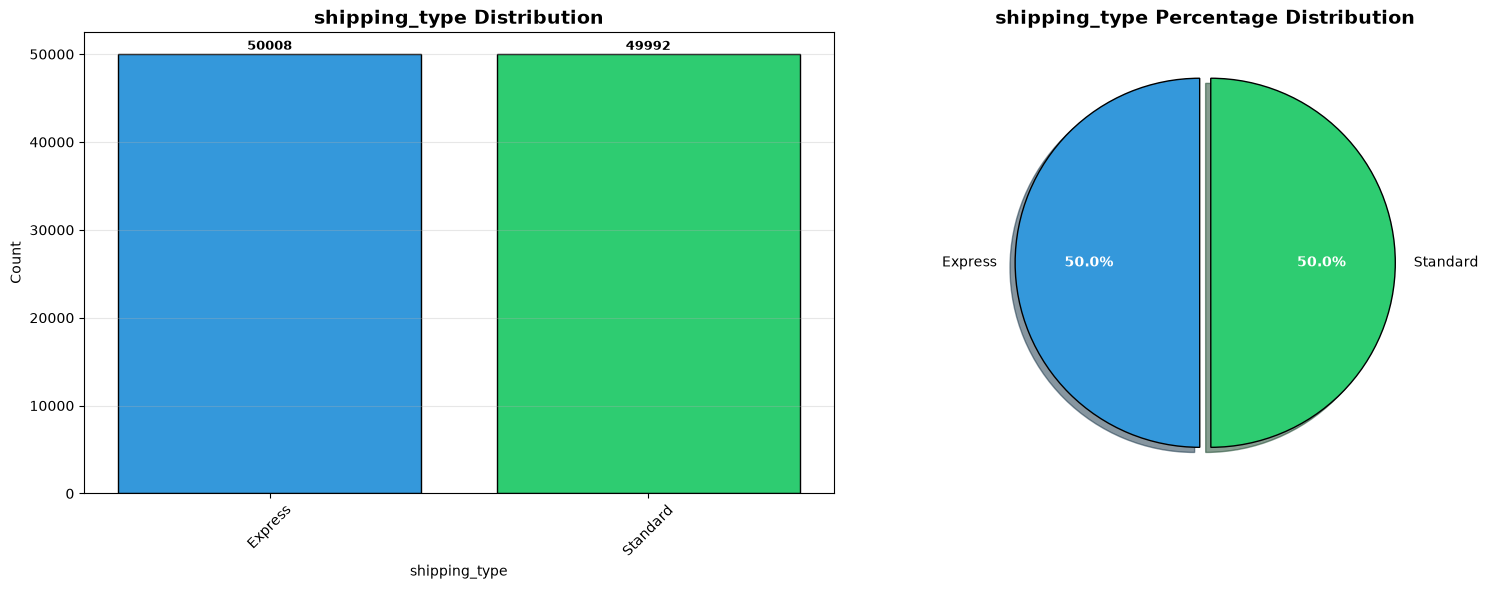

UNIVARIATE ANALYSIS : return_status
return_status
No     85189
Yes    14811
Name: count, dtype: int64


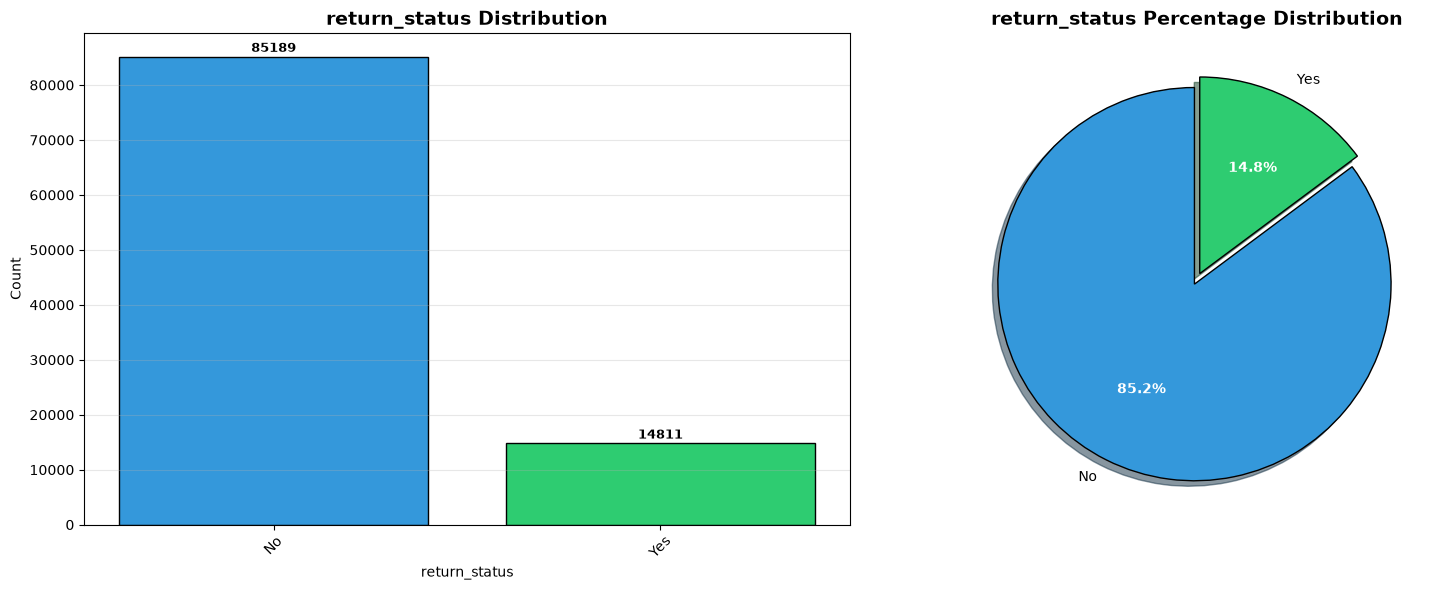

In [ ]:
# One common color palette for both charts
colors = [
    '#3498db', '#2ecc71', '#e74c3c', '#9b59b6',
    '#f39c12', '#1abc9c', '#e67e22', '#34495e',
    '#d35400', '#16a085'
]

for col in cat_cols:

    print("="*80)
    print(f"UNIVARIATE ANALYSIS : {col}")
    print("="*80)

    unique = df[col].nunique()

    print(df[col].value_counts())

    # Use Top 10 categories if there are many unique values
    if unique > 20:
        values = df[col].value_counts().head(10)
    else:
        values = df[col].value_counts()

    # Match the number of colors to the number of categories
    chart_colors = colors[:len(values)]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # ---------------- Bar Chart ----------------

    bars = ax[0].bar(
        values.index.astype(str),
        values.values,
        color=chart_colors,
        edgecolor='black'
    )

    ax[0].set_title(f'{col} Distribution',
                    fontsize=14,
                    fontweight='bold')

    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Count")
    ax[0].tick_params(axis='x', rotation=45)
    ax[0].grid(axis='y', alpha=0.3)

    # Value Labels
    for bar in bars:
        height = bar.get_height()
        ax[0].text(
            bar.get_x() + bar.get_width()/2,
            height + values.max()*0.01,
            f'{int(height)}',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

    # ---------------- Pie Chart ----------------

    wedges, texts, autotexts = ax[1].pie(
        values.values,
        labels=values.index.astype(str),
        colors=chart_colors,          # SAME COLORS AS BAR CHART
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.03]*len(values),
        shadow=True,
        wedgeprops=dict(edgecolor='black')
    )

    plt.setp(autotexts,
             size=10,
             weight='bold',
             color='white')

    ax[1].set_title(f'{col} Percentage Distribution',
                    fontsize=14,
                    fontweight='bold')

    plt.tight_layout()
    plt.show()

## Key Findings

### Gender Distribution
- The customer base is **almost equally distributed between male and female customers**, indicating balanced participation across both genders.
- This suggests that the e-commerce platform effectively caters to a diverse customer demographic without significant gender bias.

---

### City-wise Distribution
- Customer transactions are **uniformly distributed across the selected cities**, indicating a broad and well-established market presence.
- No single city overwhelmingly dominates the customer base, reflecting consistent customer engagement across different urban locations.

---

### State-wise Distribution
- Most states contribute **approximately 10,000 customer transactions**, demonstrating a relatively balanced geographical distribution.
- **Maharashtra** stands out with **around 20,000 transactions**, making it the highest contributing state in terms of customer orders.
- This suggests that Maharashtra represents a key market for the business and may offer further opportunities for targeted marketing and expansion.

---

### Customer Segment Analysis
- The **New Customer** segment accounts for the largest share of transactions, followed by **Regular** and **Premium** customers.
- A higher proportion of new customers indicates that the business is continuously acquiring new users, reflecting strong market penetration and growth potential.
- Converting these new customers into regular and premium customers through effective retention strategies could further enhance long-term profitability.

---

### Return Status Analysis
- The majority of orders are marked as **"No Return"**, while only a small proportion of transactions are returned.
- A low return rate indicates that customers are generally satisfied with the products and services offered.
- This reflects effective product quality, accurate order fulfillment, and efficient business operations, all of which contribute to improved customer satisfaction and brand trust.

In [ ]:
# Date Column Analysis
print("="*60)
print("ORDER DATE SUMMARY")
print("="*60)

start_date = df['order_date'].min()
end_date = df['order_date'].max()
time_span = (end_date - start_date).days

print(f"Start Date : {start_date.date()}")
print(f"End Date   : {end_date.date()}")
print(f"Time Span  : {time_span} days ({round(time_span/365,2)} years)")

ORDER DATE SUMMARY
Start Date : 2023-01-01
End Date   : 2025-12-30
Time Span  : 1094 days (3.0 years)


### Key Findings

- The dataset is intended to cover a **three-year period**, from **1 January 2023** to **31 December 2025**.
- A complete three-year duration, including the leap year **2024**, should contain **1,096 calendar days**.
- However, the dataset contains records spanning only **1,094 days**, indicating that **two calendar days are missing**.
- Based on the available date range, one of the missing dates is **31 December 2025**, as the dataset ends on **30 December 2025**.
- The second missing date cannot be determined from the date range alone and requires further validation by identifying missing dates within the sequence.
- Although this represents a minor data completeness issue, it should be documented before conducting time-series or trend analysis.

In [18]:
# Find missing dates in the dataset

all_dates = pd.date_range(
    start=df['order_date'].min(),
    end='2025-12-31'
)

missing_dates = all_dates.difference(df['order_date'].drop_duplicates())

print("Missing Dates:")
print(missing_dates)

Missing Dates:
DatetimeIndex(['2025-12-31'], dtype='datetime64[us]', freq='D')


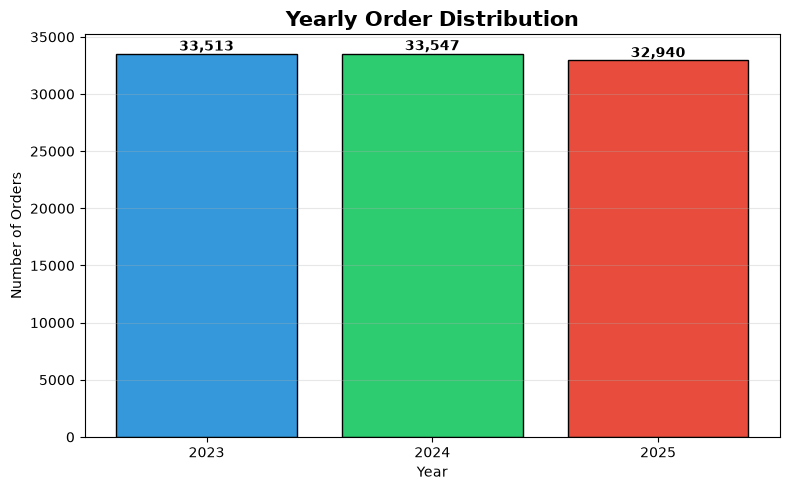

In [19]:
# Extract year
df['Year'] = df['order_date'].dt.year

# Count orders by year
yearly_orders = df['Year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

bars = plt.bar(
    yearly_orders.index.astype(str),
    yearly_orders.values,
    color=['#3498db', '#2ecc71', '#e74c3c'],
    edgecolor='black'
)

plt.title('Yearly Order Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.grid(axis='y', alpha=0.3)

# Value Labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### Key Findings

- Order volumes remain fairly stable across all three years.
- **2025** shows a marginally lower number of orders than **2023** and **2024**.
- This slight reduction is expected, as the dataset does not include transactions for **31 December 2025**.
- Overall, the yearly trend suggests consistent customer demand throughout the analysis period.

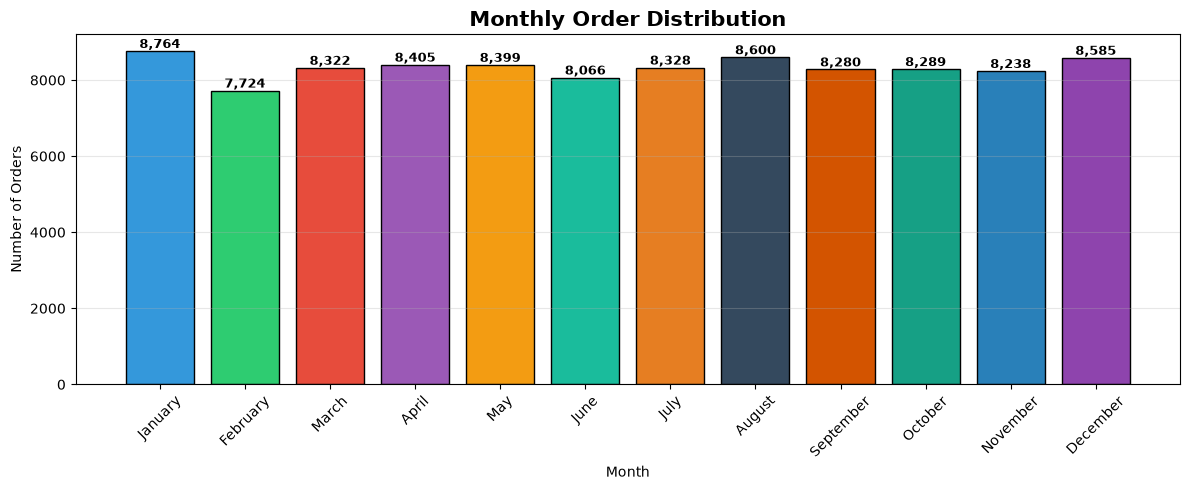

In [20]:
import calendar
# Extract month
df['Month'] = df['order_date'].dt.month

monthly_orders = (
    df['Month']
    .value_counts()
    .sort_index()
)

month_names = [calendar.month_name[i] for i in monthly_orders.index]

colors = [
    '#3498db', '#2ecc71', '#e74c3c', '#9b59b6',
    '#f39c12', '#1abc9c', '#e67e22', '#34495e',
    '#d35400', '#16a085', '#2980b9', '#8e44ad'
]

plt.figure(figsize=(12,5))

bars = plt.bar(
    month_names,
    monthly_orders.values,
    color=colors,
    edgecolor='black'
)

plt.title('Monthly Order Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Value Labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f'{height:,}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### Key Findings

- The monthly distribution indicates that **order volumes remain relatively consistent throughout the year**, suggesting stable customer purchasing behavior.
- A **slight decline in orders is observed during February**, making it the month with comparatively lower transaction volume.
- **January, August, and December** record **slightly higher order volumes** than the other months, indicating periods of increased customer activity.
- The higher order counts during these months may be influenced by factors such as seasonal demand, promotional campaigns, festive shopping, or year-end purchasing trends.
- Overall, the monthly trend demonstrates a **fairly uniform distribution of orders**, with only minor seasonal fluctuations and no significant irregularities.

### Bivarient Analysis

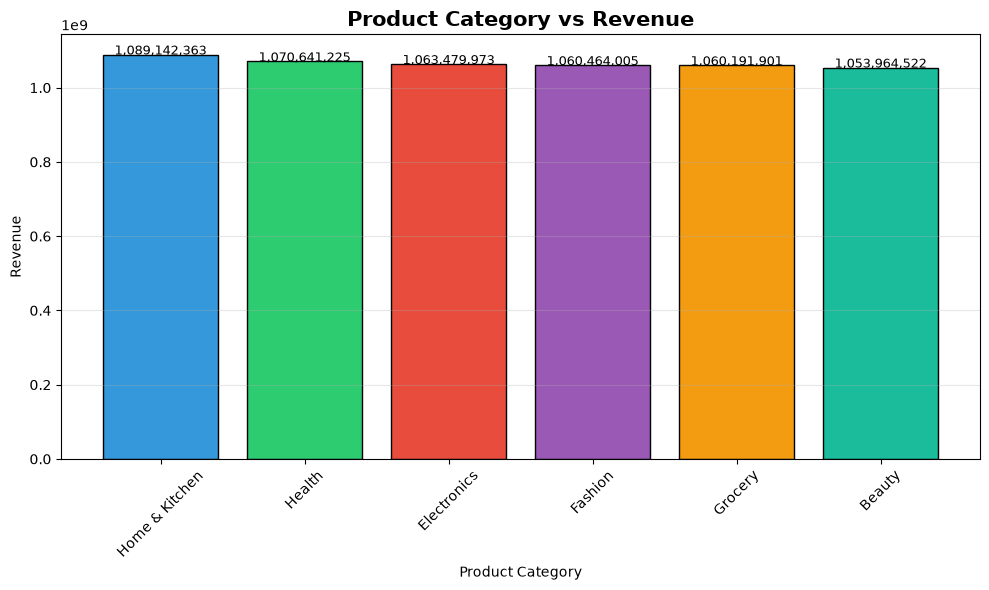

In [ ]:
category_revenue = (
    df.groupby('product_category')['final_price']
    .sum()
    .sort_values(ascending=False)
)

colors = ['#3498db','#2ecc71','#e74c3c','#9b59b6',
          '#f39c12','#1abc9c','#34495e','#e67e22']

plt.figure(figsize=(10,6))

bars = plt.bar(category_revenue.index,
               category_revenue.values,
               color=colors,
               edgecolor='black')

plt.title("Product Category vs Revenue", fontsize=15, fontweight='bold')
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():,.0f}',
             ha='center',
             fontsize=9)

plt.tight_layout()
plt.show()

### Product Category vs Revenue - Key Findings

- Revenue generated across the different product categories is **fairly balanced**, indicating that customer demand is well distributed among the available product categories.
- **Home & Kitchen** is the **highest revenue-generating product category**, contributing **slightly more revenue** than the other categories.
- The relatively uniform revenue distribution suggests that the business is **not heavily dependent on a single product category**, reducing revenue concentration risk.
- The slightly higher revenue from the **Home & Kitchen** category indicates stronger customer demand and presents an opportunity for targeted promotions, inventory expansion, and product diversification within this category.

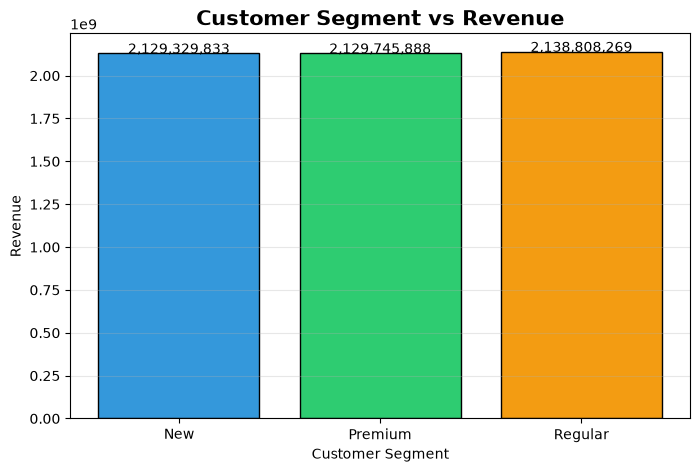

In [14]:
segment_revenue = df.groupby('customer_segment')['final_price'].sum()

colors = ['#3498db','#2ecc71','#f39c12']

plt.figure(figsize=(8,5))

bars = plt.bar(segment_revenue.index,
               segment_revenue.values,
               color=colors,
               edgecolor='black')

plt.title("Customer Segment vs Revenue", fontsize=15, fontweight='bold')
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():,.0f}',
             ha='center')

plt.show()

### Customer Segment vs Revenue - Key Findings

- **Regular customers** contribute the **highest share of total revenue**, making them the most valuable customer segment for the business.
- **Premium customers** generate the **second-highest revenue**, demonstrating their significant contribution despite representing a smaller customer base.
- **New customers** contribute the **least revenue** among the three segments, which is expected as they are in the initial stage of their customer journey.
- The findings highlight the importance of **customer retention**, as repeat purchases from regular customers play a crucial role in driving overall business revenue.
- Converting **new customers into regular and premium customers** through loyalty programs, personalized recommendations, and targeted marketing campaigns can further enhance long-term revenue growth.

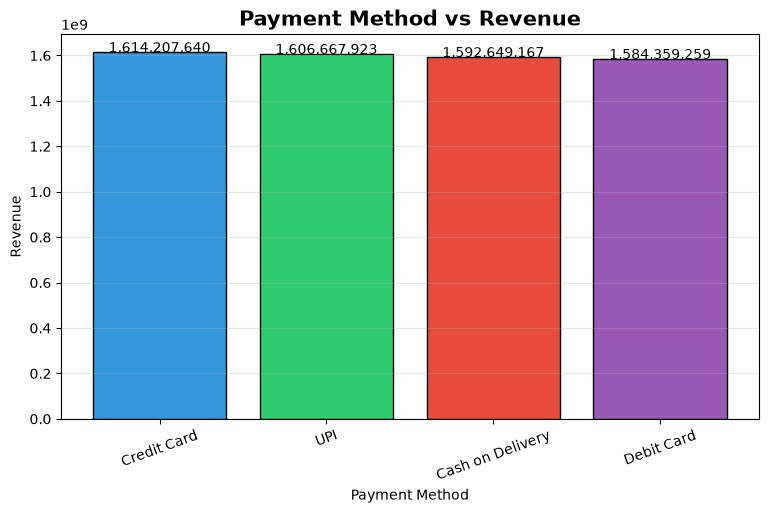

In [15]:
payment = df.groupby('payment_method')['final_price'].sum().sort_values(ascending=False)

colors = ['#3498db','#2ecc71','#e74c3c','#9b59b6','#f39c12']

plt.figure(figsize=(9,5))

bars = plt.bar(payment.index,
               payment.values,
               color=colors,
               edgecolor='black')

plt.title("Payment Method vs Revenue", fontsize=15, fontweight='bold')
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():,.0f}',
             ha='center')

plt.show()

### Payment Method vs Revenue - Key Findings

- Revenue generation is **fairly evenly distributed across all payment methods**, indicating that customers are comfortable using a variety of payment options.
- **Credit Card** and **UPI** emerge as the **top revenue-contributing payment methods**, generating slightly higher revenue compared to the other payment options.
- The balanced distribution suggests that the business has successfully adopted multiple payment channels, ensuring convenience and accessibility for customers.
- The higher contribution from **Credit Card** and **UPI** reflects their growing popularity and customer preference for secure and seamless digital payment methods.
- Maintaining a diverse range of payment options while further enhancing digital payment experiences can improve customer satisfaction and support continued revenue growth.

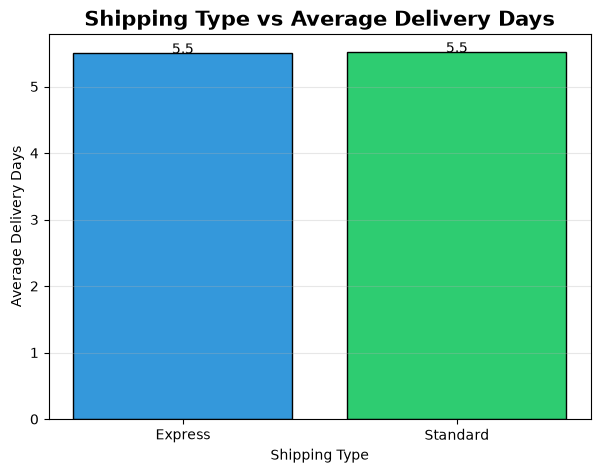

In [16]:
shipping = df.groupby('shipping_type')['delivery_days'].mean()

colors=['#3498db','#2ecc71','#e74c3c']

plt.figure(figsize=(7,5))

bars=plt.bar(shipping.index,
             shipping.values,
             color=colors,
             edgecolor='black')

plt.title("Shipping Type vs Average Delivery Days",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Shipping Type")
plt.ylabel("Average Delivery Days")

plt.grid(axis='y',alpha=0.3)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.1f}',
             ha='center')

plt.show()

### Shipping Type vs Delivery Days - Key Findings

- Both **Standard** and **Express** shipping methods maintain an **average delivery time of approximately 5.5 days**.
- The minimal difference in average delivery time suggests that both shipping options provide a **consistent and reliable delivery experience**.
- This indicates that the logistics and supply chain operations are well managed, ensuring timely deliveries regardless of the shipping method selected.
- Since the average delivery time is nearly identical for both shipping types, further analysis may be required to evaluate whether the **Express** shipping service provides sufficient value to customers in terms of delivery speed.

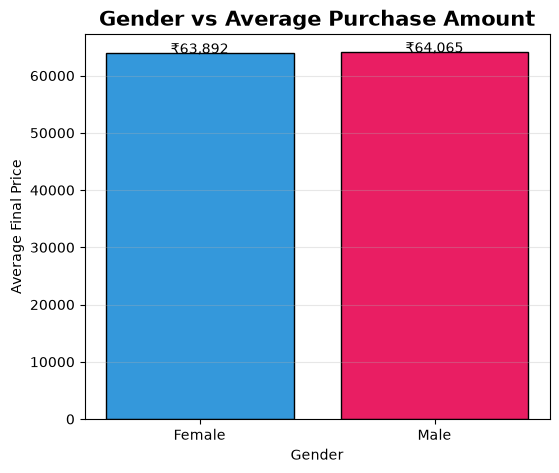

In [17]:
gender = df.groupby('gender')['final_price'].mean()

colors=['#3498db','#e91e63']

plt.figure(figsize=(6,5))

bars=plt.bar(gender.index,
             gender.values,
             color=colors,
             edgecolor='black')

plt.title("Gender vs Average Purchase Amount",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Gender")
plt.ylabel("Average Final Price")

plt.grid(axis='y',alpha=0.3)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f'₹{bar.get_height():,.0f}',
             ha='center')

plt.show()

### Gender vs Purchase Amount - Key Findings

- Both **male** and **female** customers contribute almost equally to the overall e-commerce customer base, indicating balanced participation across genders.
- The **average purchase amount** is slightly higher for **male customers** compared to female customers.
- This suggests that male customers tend to purchase **slightly more expensive products**, **larger quantities of products**, or a combination of both, resulting in a higher average order value.
- Despite this small difference in spending behavior, the overall contribution from both genders remains relatively balanced, indicating that the platform successfully caters to a diverse customer base.
- These insights can help the business design targeted marketing strategies and personalized product recommendations while maintaining an inclusive customer experience.

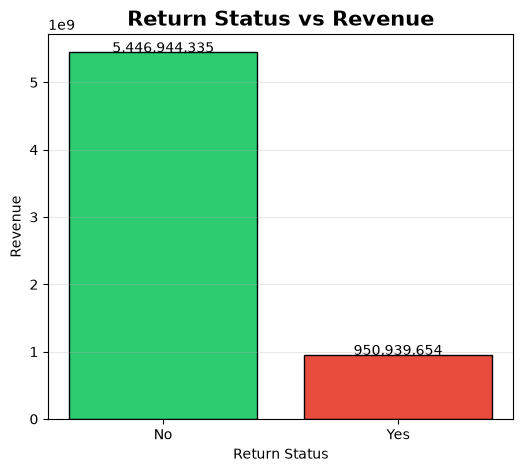

In [18]:
returns = df.groupby('return_status')['final_price'].sum()

colors=['#2ecc71','#e74c3c']

plt.figure(figsize=(6,5))

bars=plt.bar(returns.index,
             returns.values,
             color=colors,
             edgecolor='black')

plt.title("Return Status vs Revenue",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Return Status")
plt.ylabel("Revenue")

plt.grid(axis='y',alpha=0.3)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():,.0f}',
             ha='center')

plt.show()

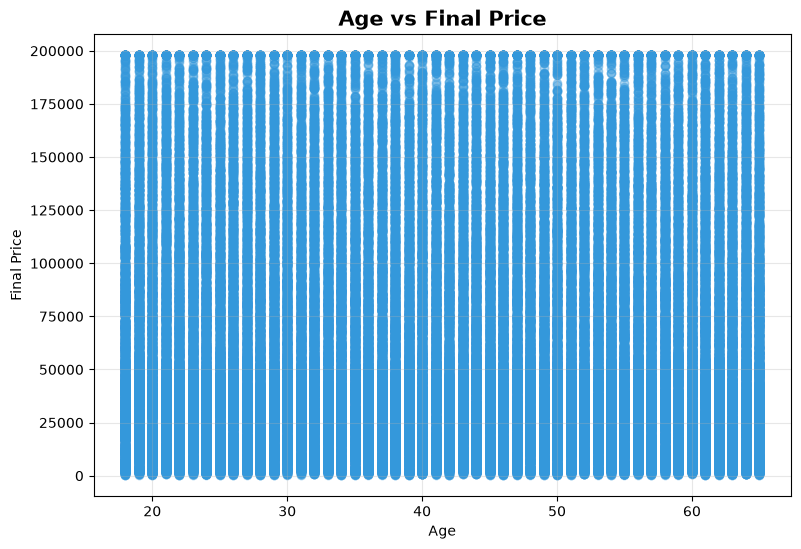

In [19]:
plt.figure(figsize=(9,6))

plt.scatter(df['age'],
            df['final_price'],
            color='#3498db',
            alpha=0.4)

plt.title("Age vs Final Price",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Age")
plt.ylabel("Final Price")

plt.grid(alpha=0.3)

plt.show()

Correlation Matrix:
                          age  product_price  quantity  discount_percentage  \
age                  1.000000      -0.000814 -0.000129            -0.004035   
product_price       -0.000814       1.000000  0.000950            -0.002886   
quantity            -0.000129       0.000950  1.000000            -0.003579   
discount_percentage -0.004035      -0.002886 -0.003579             1.000000   
final_price         -0.000928       0.732838  0.576573            -0.134231   
delivery_days       -0.003954       0.001554  0.004017            -0.000453   

                     final_price  delivery_days  
age                    -0.000928      -0.003954  
product_price           0.732838       0.001554  
quantity                0.576573       0.004017  
discount_percentage    -0.134231      -0.000453  
final_price             1.000000       0.003767  
delivery_days           0.003767       1.000000  


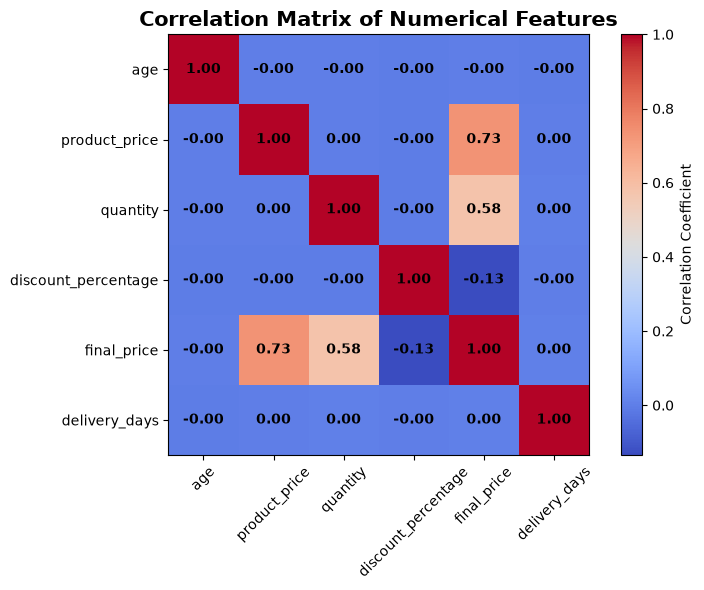

In [20]:
# Select numerical columns
num_cols = [
    'age',
    'product_price',
    'quantity',
    'discount_percentage',
    'final_price',
    'delivery_days'
]

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Display correlation values
print("Correlation Matrix:")
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(8, 6))

plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')

# Add color bar
plt.colorbar(label='Correlation Coefficient')

# Axis labels
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.yticks(range(len(num_cols)), num_cols)

# Display correlation values inside cells
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            color='black',
            fontweight='bold'
        )

plt.title("Correlation Matrix of Numerical Features",
          fontsize=15,
          fontweight='bold')

plt.tight_layout()
plt.show()

## Key Findings

- The **product price** is the primary driver of the final order value, making pricing strategy a key factor influencing revenue.
- Encouraging customers to purchase **multiple products per order** can increase the overall order value, as reflected by the moderate positive correlation between quantity and final price.
- While discounts do reduce the final payable amount, their relatively weak negative correlation suggests that the current discount strategy does not substantially diminish revenue.
- Customer **age** does not appear to influence purchasing behavior, indicating that marketing strategies can focus more on customer preferences and buying patterns rather than age demographics.
- The absence of strong correlations among most variables suggests that the dataset has **low multicollinearity**.

### Mutivarient Analysis

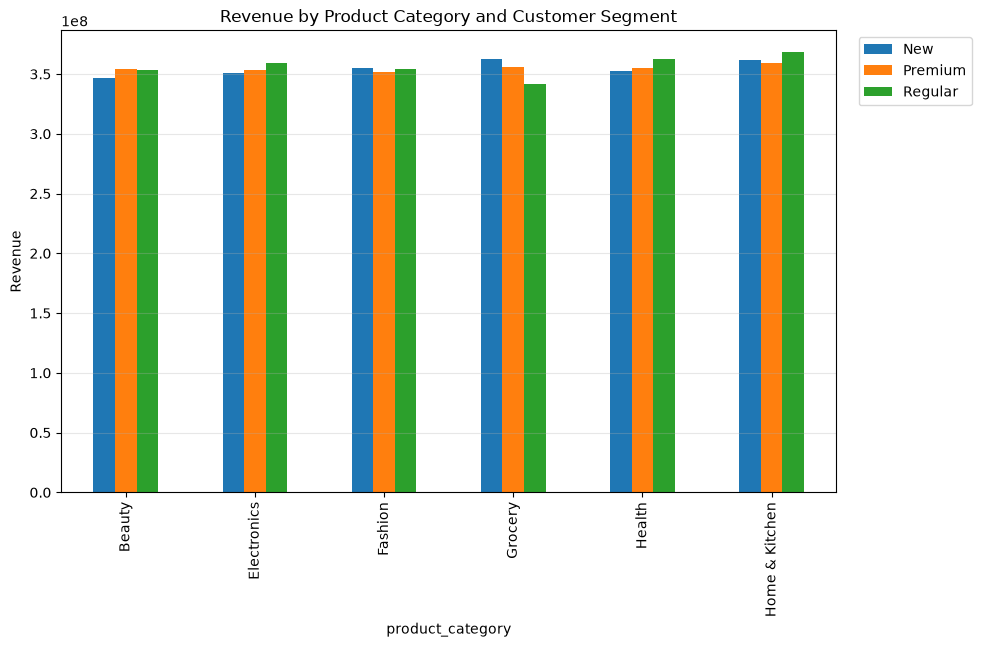

In [22]:
pivot = df.pivot_table(
    values='final_price',
    index='product_category',
    columns='customer_segment',
    aggfunc='sum'
)

pivot.plot(kind='bar', figsize=(10,6))
plt.title("Revenue by Product Category and Customer Segment")
plt.ylabel("Revenue")
plt.grid(axis='y', alpha=0.3)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.show()

### Product Category vs Customer Segment vs Revenue - Key Findings

- **New customers** generate the highest revenue from the **Grocery** category, followed by **Home & Kitchen** and the remaining product categories.
- This indicates that essential and frequently purchased products are more attractive to first-time customers, making Grocery an effective category for customer acquisition.

- **Regular** and **Premium customers** contribute the highest revenue in the **Home & Kitchen** category, followed by **Health** and **Electronics** products.
- This purchasing pattern suggests that loyal customers are more inclined to spend on higher-value and lifestyle-oriented products as they become more familiar with the platform.

- The variation in purchasing preferences across customer segments highlights the importance of **customer segmentation** in designing personalized marketing campaigns and product recommendations.

- The findings also indicate opportunities for **cross-selling and upselling**, such as encouraging new customers who frequently purchase Grocery items to explore Home & Kitchen products, while offering exclusive promotions on Health and Electronics products to Regular and Premium customers to maximize customer lifetime value.

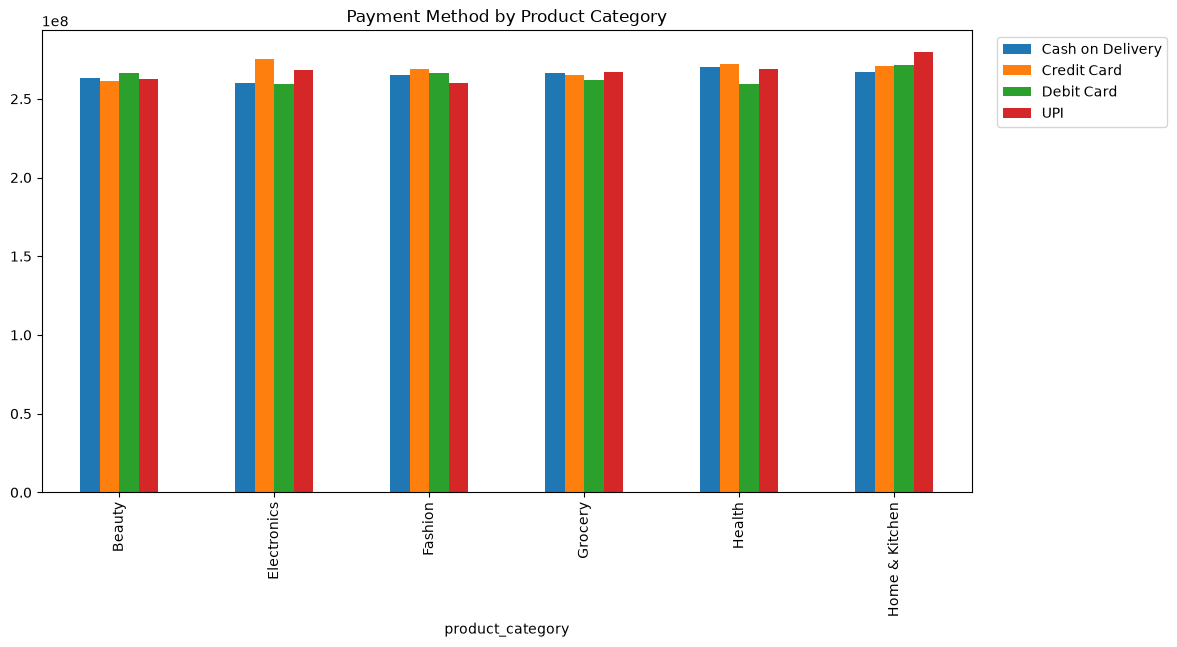

In [24]:
pivot = df.pivot_table(
    values='final_price',
    index='product_category',
    columns='payment_method',
    aggfunc='sum'
)

pivot.plot(kind='bar', figsize=(12,6))
plt.title("Payment Method by Product Category")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.show()

### Payment Method vs Product Category vs Revenue - Key Findings

- **Cash** is the most preferred payment method for purchases in the **Grocery** category, indicating that customers buying everyday essentials continue to rely on traditional payment methods.

- For **Home & Kitchen**, **Electronics**, and several other product categories, customers show a stronger preference for **digital payment methods**, particularly **UPI**, followed by **Credit Card** and **Debit Card** transactions.

- The higher adoption of digital payment options for higher-value product categories suggests increasing customer confidence in secure and convenient cashless transactions.

- The variation in payment preferences across product categories highlights the importance of offering multiple payment options to enhance customer convenience and improve the overall shopping experience.

- The growing use of **UPI** reflects the rapid adoption of digital payment platforms, making it a key payment channel for the e-commerce business.

In [25]:
pivot = df.pivot_table(
    values='delivery_days',
    index='shipping_type',
    columns='return_status',
    aggfunc='mean'
)

print(pivot)

return_status        No       Yes
shipping_type                    
Express        5.495076  5.510661
Standard       5.514729  5.507615


### Shipping Type vs Return Status vs Delivery Days - Key Findings

- Both **Standard** and **Express** shipping methods have an average delivery time of approximately **5.5 days**, indicating minimal difference in delivery performance.
- The similar delivery times suggest that customers may not be experiencing the expected speed advantage from the **Express** shipping option.
- This lack of a noticeable difference in delivery time **could be one of the factors contributing to product returns**, particularly if customer expectations for faster delivery are not met.
- However, delivery time alone cannot be concluded as the sole reason for returns, as other factors such as product quality, incorrect orders, or customer preferences may also influence return decisions.
- Further analysis incorporating customer feedback or return reasons would be required to establish the exact relationship between shipping performance and product returns.

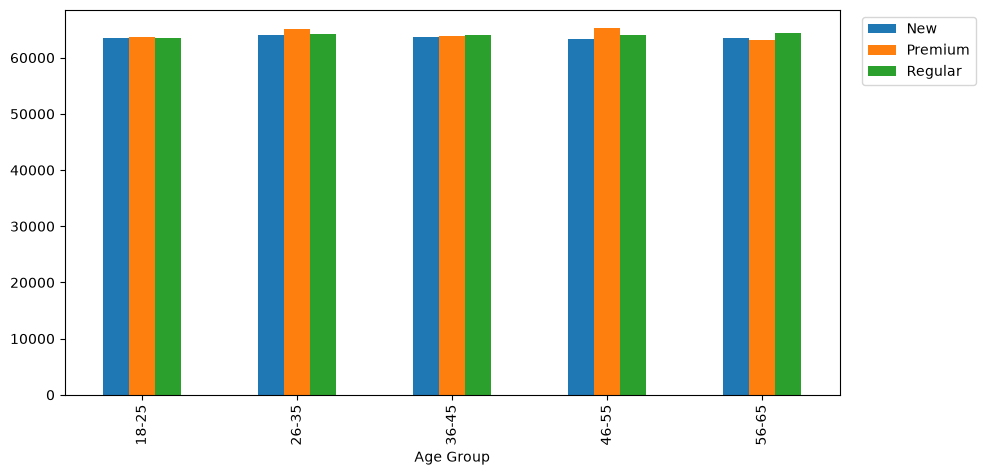

In [27]:
df['Age Group'] = pd.cut(
    df['age'],
    bins=[18,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-65']
)

pivot = df.pivot_table(
    values='final_price',
    index='Age Group',
    columns='customer_segment',
    aggfunc='mean'
)

pivot.plot(kind='bar', figsize=(10,5))
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.show()

### Age Group vs Customer Segment vs Average Purchase Amount - Key Findings

- The **average purchase amount remains relatively consistent across all age groups**, with only minor variations, indicating stable spending behavior irrespective of age.

- Across most age groups, the difference in average purchase amount between **New, Regular, and Premium customers** is relatively small, suggesting that customer segment has only a limited influence on average spending within each age group.

- In the **26–35** and **46–55** age groups, **Premium customers** record the highest average purchase amount, indicating a greater tendency to purchase higher-value products or place larger orders.

- In the **56–65** age group, **Regular customers** exhibit the highest average purchase amount, highlighting the strong purchasing power and loyalty of older repeat customers.

- The **18–25** age group shows nearly identical average purchase amounts across all customer segments, suggesting similar spending patterns among younger customers regardless of their customer status.

- Overall, the analysis indicates that **age alone is not a strong determinant of purchase value**, as average spending remains fairly uniform across different age groups. This observation is also consistent with the earlier correlation analysis, which showed that **age has little to no linear relationship with the final purchase amount.**

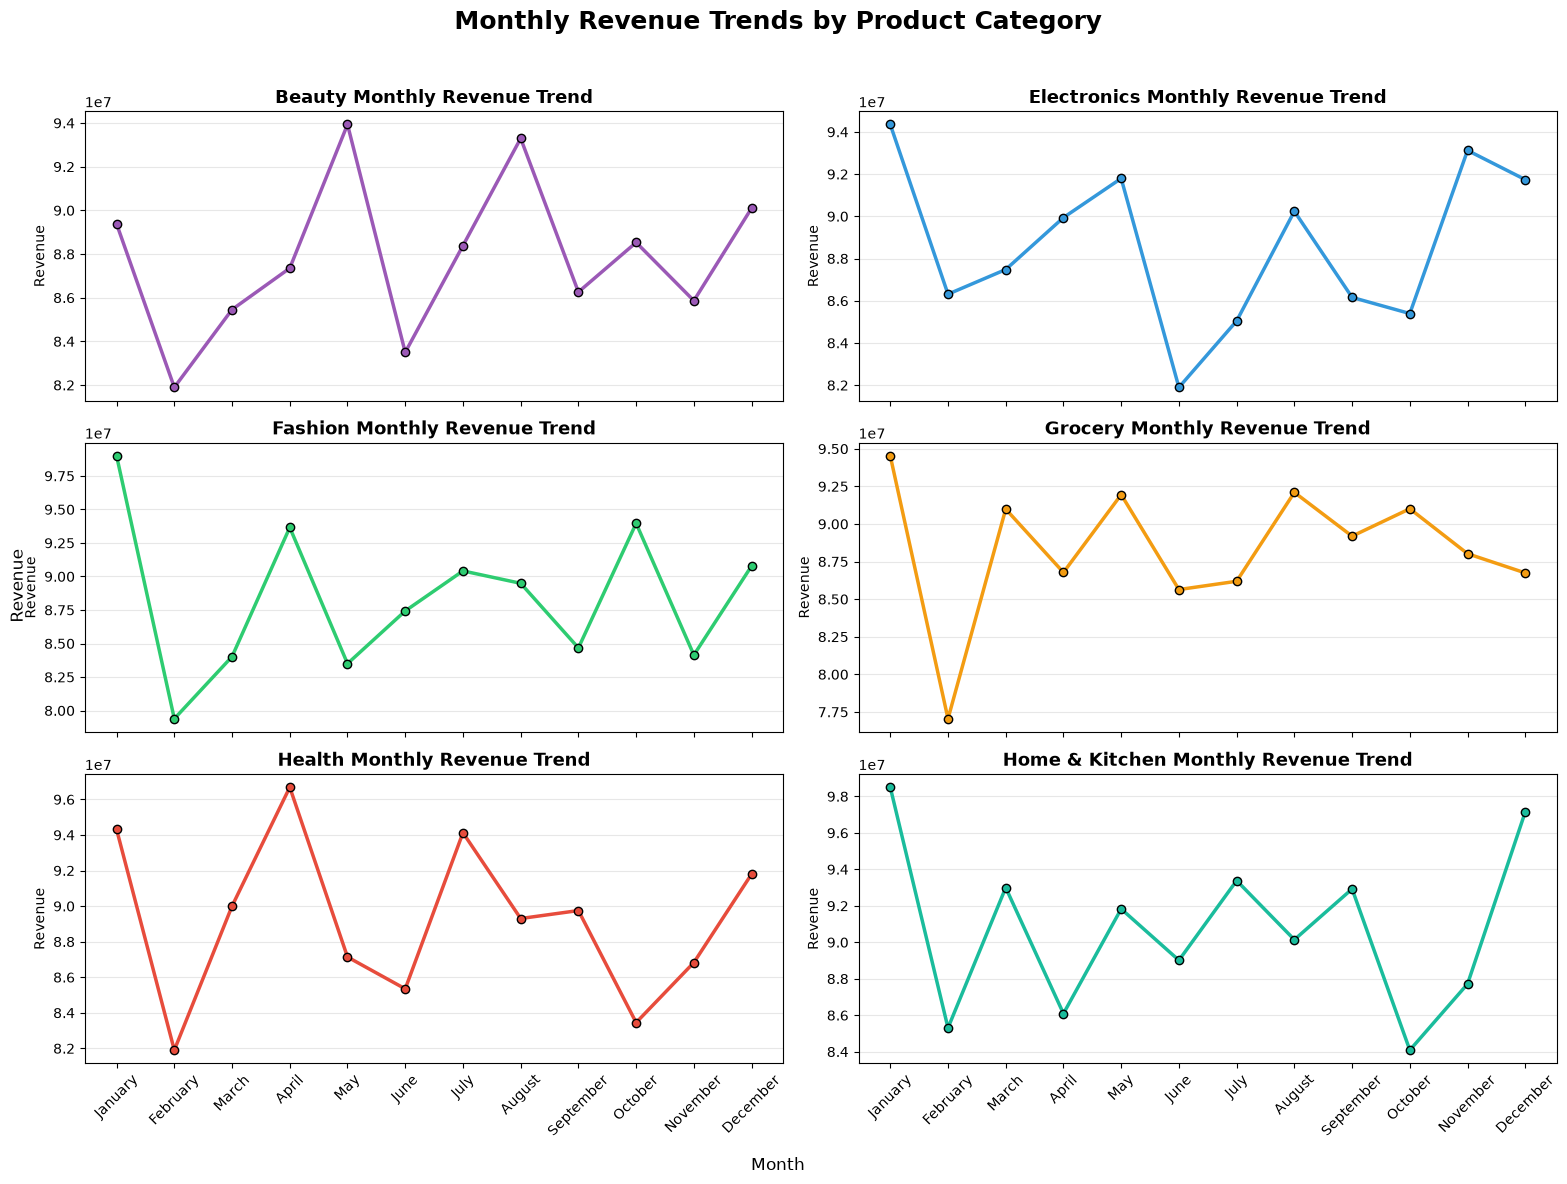

In [11]:
# Create Month column
df['Month'] = df['order_date'].dt.month_name()

# Define month order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Create pivot table
pivot = df.pivot_table(
    values='final_price',
    index='Month',
    columns='product_category',
    aggfunc='sum'
)

# Arrange months chronologically
pivot = pivot.reindex(month_order)

# Different colors for each category
colors = [
    '#9b59b6',  # Beauty
    '#3498db',  # Electronics
    '#2ecc71',  # Fashion
    '#f39c12',  # Grocery
    '#e74c3c',  # Home & Kitchen
    '#1abc9c'   # Health
]

# Create subplots
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 12),
    sharex=True
)

axes = axes.flatten()

# Plot each category
for ax, category, color in zip(axes, pivot.columns, colors):

    ax.plot(
        pivot.index,
        pivot[category],
        marker='o',
        linewidth=2.5,
        color=color,
        markerfacecolor=color,
        markeredgecolor='black'
    )

    ax.set_title(
        f"{category} Monthly Revenue Trend",
        fontsize=13,
        fontweight='bold'
    )

    ax.set_ylabel("Revenue")
    ax.grid(axis='y', alpha=0.3)

    ax.tick_params(axis='x', rotation=45)

# Common labels
fig.supxlabel("Month", fontsize=12)
fig.supylabel("Revenue", fontsize=12)

# Overall title
fig.suptitle(
    "Monthly Revenue Trends by Product Category",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

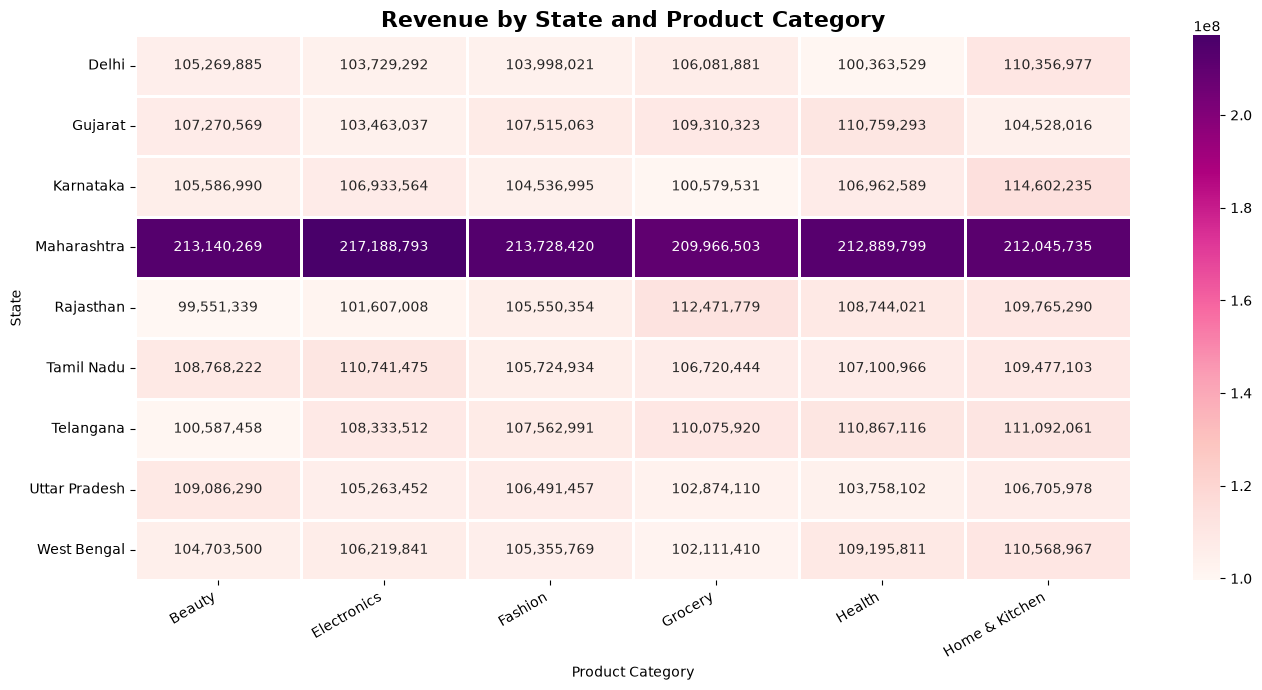

In [8]:
import seaborn as sns

pivot = df.pivot_table(
    values='final_price',
    index='state',
    columns='product_category',
    aggfunc='sum'
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    pivot,
    annot=True,
    fmt=',.0f',
    cmap='RdPu',
    linewidths=1,
    linecolor='white'
)

plt.title(
    "Revenue by State and Product Category",
    fontsize=16,
    fontweight='bold'
)
plt.xlabel("Product Category")
plt.ylabel("State")

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

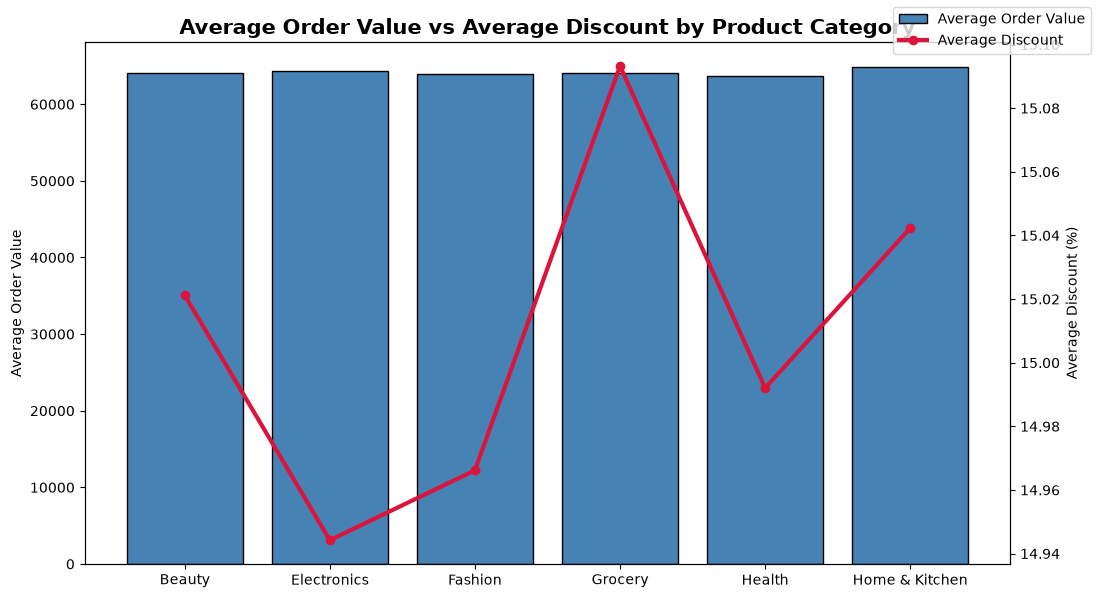

In [14]:
summary = df.groupby('product_category').agg(
    Avg_Order_Value=('final_price', 'mean'),
    Avg_Discount=('discount_percentage', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(11,6))

ax1.bar(
    summary['product_category'],
    summary['Avg_Order_Value'],
    color='steelblue',
    edgecolor='black',
    label='Average Order Value'
)

ax1.set_ylabel("Average Order Value")

ax2 = ax1.twinx()

ax2.plot(
    summary['product_category'],
    summary['Avg_Discount'],
    color='crimson',
    marker='o',
    linewidth=3,
    label='Average Discount'
)

ax2.set_ylabel("Average Discount (%)")

plt.title("Average Order Value vs Average Discount by Product Category",
          fontsize=15,
          fontweight='bold')

plt.xticks(rotation=30)

fig.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Average Order Value vs Average Discount by Product Category - Key Findings

- **Electronics** has the **lowest average discount** among all product categories, indicating that electronic products are generally sold with minimal price reductions while maintaining strong revenue potential.

- **Grocery** offers the **highest average discount percentage**, making it the most heavily discounted product category. This pricing strategy is likely aimed at attracting customers and encouraging frequent purchases of essential items.

- Despite offering the highest discounts, **Grocery** also records the **highest average order value**, suggesting that customers tend to purchase groceries in larger quantities or higher-value baskets, offsetting the impact of discounts.

- **Home & Kitchen** ranks as the **second-highest category in terms of average order value**, indicating strong customer demand and a significant contribution to overall business revenue.

- The remaining product categories follow the order:
  **Beauty → Health → Fashion → Electronics** in terms of average order value.

- The analysis suggests that **higher discounts do not necessarily result in lower order values**. Categories such as Grocery successfully combine attractive discounts with high customer spending, making them effective drivers of sales volume and revenue.

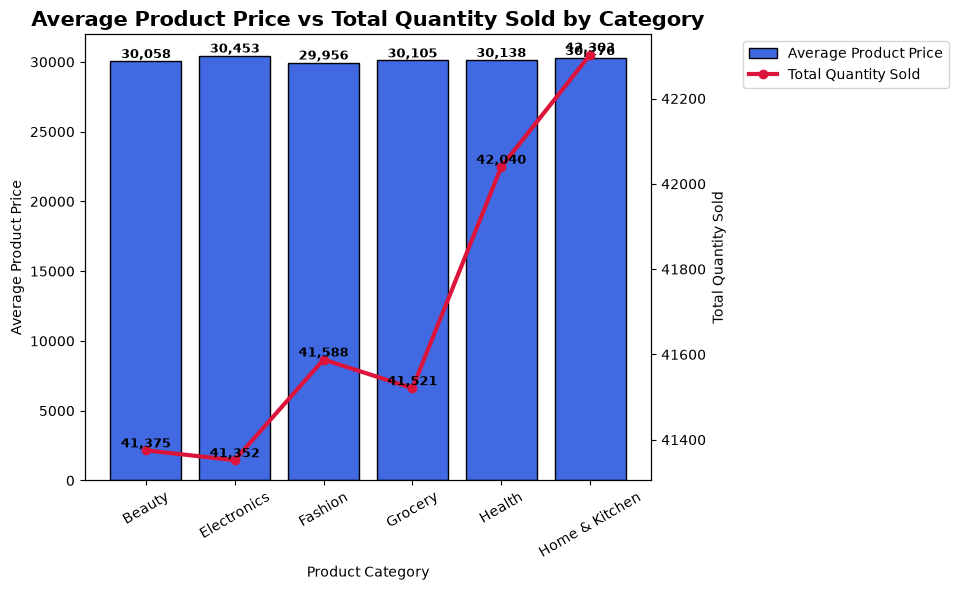

In [10]:
price_quantity = df.groupby('product_category').agg(
    Average_Price=('product_price', 'mean'),
    Total_Quantity=('quantity', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Average Price
bars = ax1.bar(
    price_quantity['product_category'],
    price_quantity['Average_Price'],
    color='royalblue',
    edgecolor='black',
    label='Average Product Price'
)

ax1.set_xlabel("Product Category")
ax1.set_ylabel("Average Product Price")
ax1.tick_params(axis='x', rotation=30)

# Add labels
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Quantity Sold
ax2 = ax1.twinx()

ax2.plot(
    price_quantity['product_category'],
    price_quantity['Total_Quantity'],
    color='crimson',
    marker='o',
    linewidth=3,
    label='Total Quantity Sold'
)

ax2.set_ylabel("Total Quantity Sold")

# Add quantity labels
for i, value in enumerate(price_quantity['Total_Quantity']):
    ax2.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    "Average Product Price vs Total Quantity Sold by Category",
    fontsize=15,
    fontweight='bold'
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    bbox_to_anchor=(1.15, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Key Findings: Average Product Price vs Total Quantity Sold

- The **average product price remains nearly consistent across all product categories**, ranging from approximately **₹29,956 to ₹30,453**.
- **Home & Kitchen** records the **highest total quantity sold**, despite having an average product price similar to other categories.
- **Electronics** has the lowest quantity sold, while its average product price is among the highest.
- The results indicate that **product price alone does not have a strong impact on total quantity sold** across categories.
- **Home & Kitchen** demonstrates the strongest overall sales performance, combining a competitive average price with the highest sales volume.

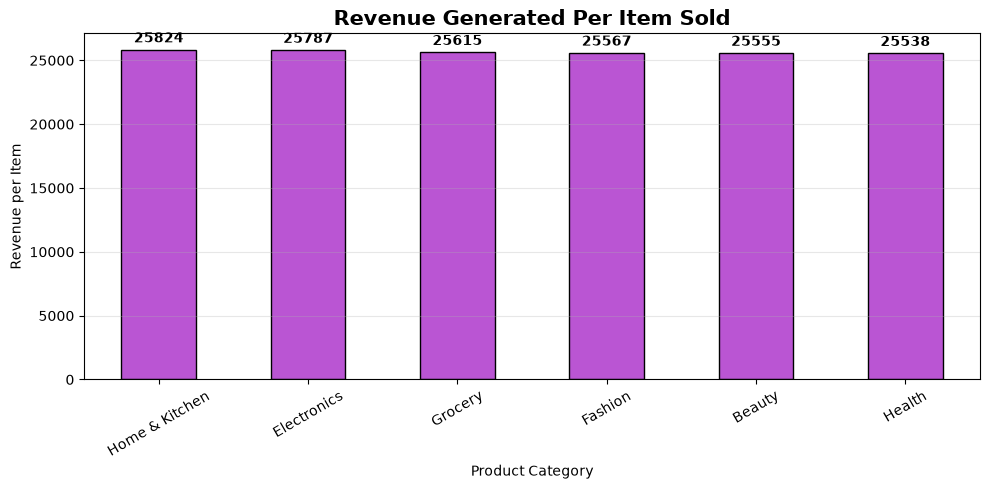

In [22]:
eff = df.groupby('product_category').agg(
    Revenue=('final_price', 'sum'),
    Quantity=('quantity', 'sum')
)

eff['Revenue_per_Item'] = eff['Revenue'] / eff['Quantity']

ax = eff.sort_values(
    'Revenue_per_Item',
    ascending=False
)['Revenue_per_Item'].plot(
    kind='bar',
    figsize=(10, 5),
    color='mediumorchid',
    edgecolor='black'
)

plt.title("Revenue Generated Per Item Sold", fontsize=15, fontweight='bold')
plt.xlabel("Product Category")
plt.ylabel("Revenue per Item")
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Revenue Generated per Item Sold - Key Findings

- The **revenue generated per item sold is relatively consistent across all product categories**, indicating a balanced pricing strategy throughout the business.

- The difference in revenue generated per item among the categories is **minimal (approximately ₹100)**, suggesting that no single category significantly outperforms the others on a per-item basis.

- **Home & Kitchen** records the **highest revenue generated per item sold**, making it the most profitable category on a per-unit basis, although the margin over other categories is relatively small.

- The consistent revenue per item across categories indicates that the business maintains a fairly uniform product pricing structure while generating stable returns from each category.

- Since the variation is minimal, overall revenue growth is likely influenced more by **sales volume and customer demand** than by differences in revenue generated per individual item.

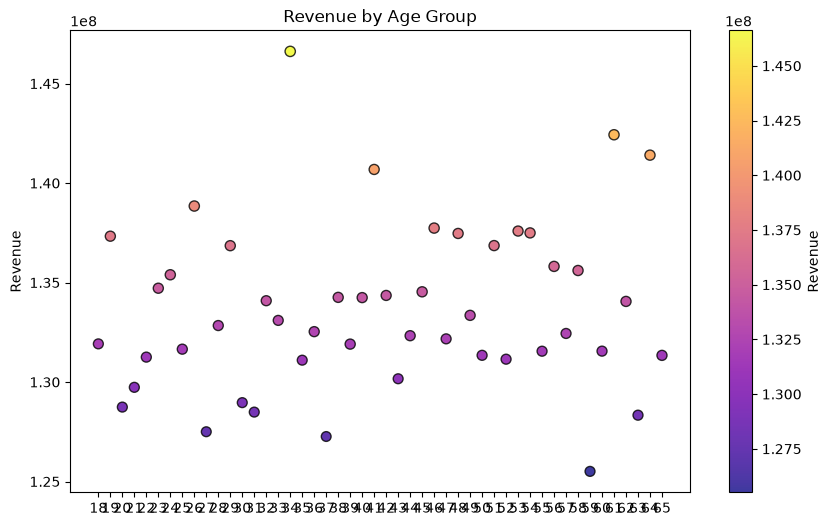

In [19]:
age = df.groupby('age').agg(
    Revenue=('final_price','sum'),
    Orders=('order_id','count')
)

plt.figure(figsize=(10,6))

plt.scatter(
    age.index.astype(str),
    age['Revenue'],
    s=age['Orders']/40,
    c=age['Revenue'],
    cmap='plasma',
    alpha=.8,
    edgecolors='black'
)

plt.colorbar(label="Revenue")

plt.title("Revenue by Age Group")

plt.ylabel("Revenue")

plt.show()

### Key Findings: Revenue by Age Group

- Revenue remains relatively consistent across different age groups, with no clear increasing or decreasing trend.
- Overall, the variation in revenue across age groups is relatively small, indicating that **age alone does not strongly influence revenue generation**.
- Customer segment and purchasing behavior may have a stronger impact on revenue than age.

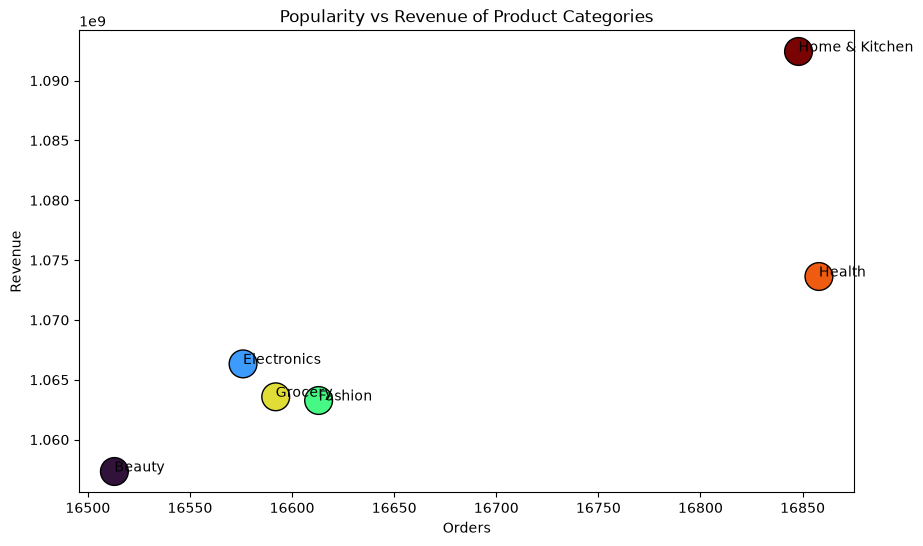

In [20]:
summary = df.groupby('product_category').agg(
    Orders=('order_id','count'),
    Revenue=('final_price','sum')
)

plt.figure(figsize=(10,6))

plt.scatter(
    summary['Orders'],
    summary['Revenue'],
    s=400,
    c=range(len(summary)),
    cmap='turbo',
    edgecolors='black'
)

for i in summary.index:
    plt.text(
        summary.loc[i,'Orders'],
        summary.loc[i,'Revenue'],
        i
    )

plt.xlabel("Orders")

plt.ylabel("Revenue")

plt.title("Popularity vs Revenue of Product Categories")

plt.show()

### Key Findings: Product Popularity vs Revenue

- **Home & Kitchen** has the highest number of orders and generates the highest revenue, making it the strongest-performing product category.
- **Health** records the second-highest order volume and revenue, showing strong customer demand.
- **Electronics** generates relatively high revenue despite having fewer orders than Home & Kitchen, Health, and Fashion, indicating a comparatively higher revenue contribution per order.
- **Beauty** has the lowest order volume and revenue among the categories.
- Overall, the analysis shows a positive relationship between **order volume and total revenue**, although categories such as **Electronics** may generate relatively higher revenue per order. category and beauty is the lowest

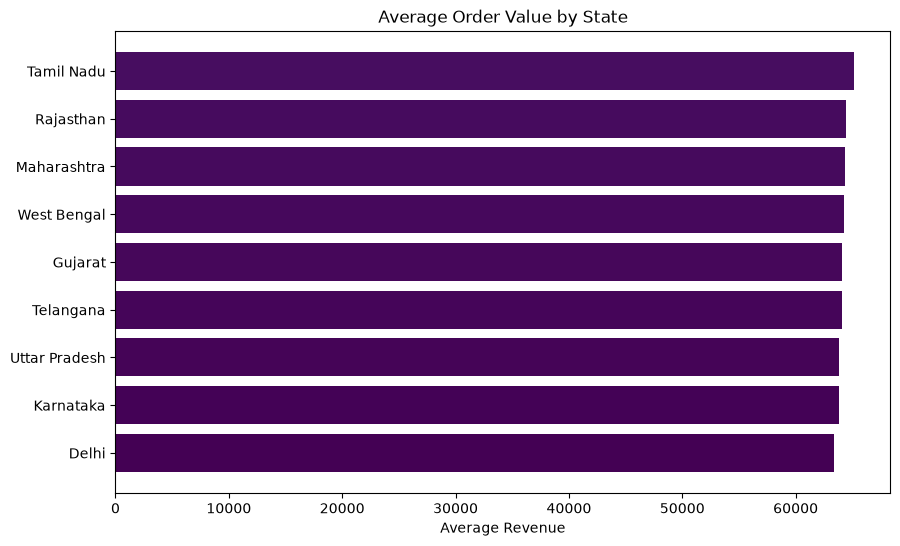

In [21]:
state = df.groupby('state')['final_price'].mean().sort_values()

plt.figure(figsize=(10,6))

bars = plt.barh(
    state.index,
    state.values,
    color=plt.cm.viridis(range(len(state)))
)

plt.title("Average Order Value by State")

plt.xlabel("Average Revenue")

plt.show()

### Key Findings: Average Order Value by State

- **Tamil Nadu** records the highest average order value among all states.
- **Delhi** has the lowest average order value, although the difference from other states is relatively small.
- Overall, the average order value remains **fairly consistent across all states**, indicating similar customer spending patterns across regions.
- The relatively small variation suggests that **geographic location has limited influence on average order value**.

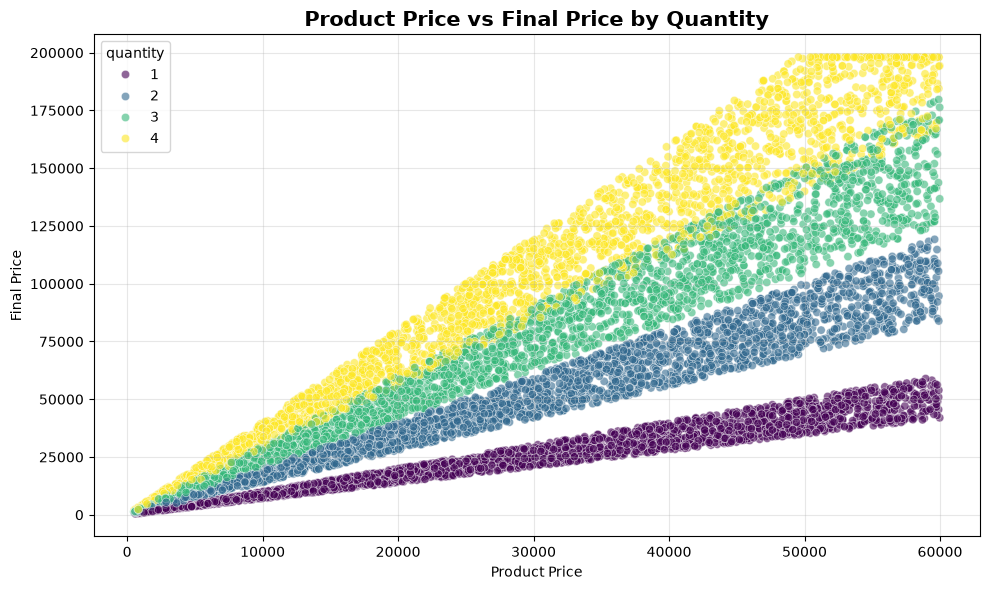

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(10000),
    x='product_price',
    y='final_price',
    hue='quantity',
    palette='viridis',
    alpha=0.6
)

plt.title("Product Price vs Final Price by Quantity",
          fontsize=15, fontweight='bold')

plt.xlabel("Product Price")
plt.ylabel("Final Price")

plt.colorbar if False else None

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Key Findings

- Final price generally increases with product price.
- Orders with higher quantities tend to have higher final prices.
- The relationship indicates that both product price and quantity are important drivers of total order value.

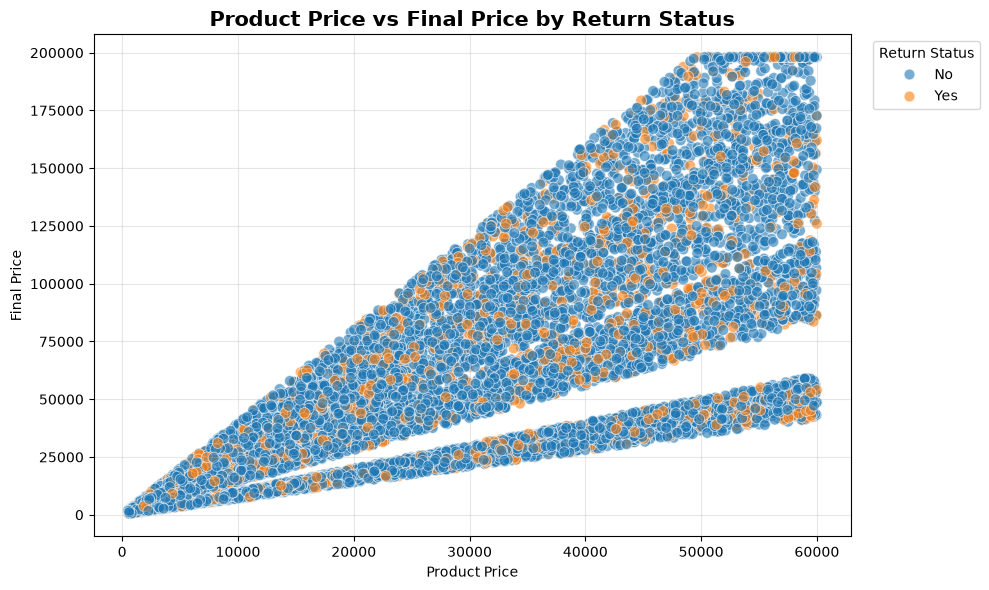

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(10000),
    x='product_price',
    y='final_price',
    hue='return_status',
    alpha=0.6,
    s=60
)

plt.title(
    "Product Price vs Final Price by Return Status",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Product Price")
plt.ylabel("Final Price")

plt.legend(
    title="Return Status",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Key Findings: Product Price vs Final Price by Return Status

- Both returned and non-returned orders are distributed across a wide range of product and final prices.
- No clear separation is observed between returned and non-returned orders based on product price or final order value.
- High-value orders are not exclusively associated with either returned or non-returned purchases.
- This suggests that product price and final order value alone may not be strong predictors of return behavior.
- Other factors such as product category, product quality, customer expectations, and delivery experience may influence returns.